# Team 4 Final Project  
# US Accidents 데이터를 활용한 교통사고 심각도 분류

## 프로젝트 개요

본 노트북은 Kaggle의 **US Accidents (2016–2023)** 데이터를 활용하여 교통사고의 심각도(`Severity`)를 예측하는 지도학습 기반 다중분류 프로젝트이다.

예측 대상인 `Severity`는 1, 2, 3, 4의 네 개 클래스로 구성되어 있다.  
본 프로젝트에서는 사고 발생 시점에서 활용 가능하다고 판단되는 시간, 위치, 기상, 도로환경 변수를 사용하여 사고 심각도를 예측한다.

## 과제 요구사항 반영 사항

- 교통 분야와 관련된 지도학습 문제 정의
- Kaggle 공개 데이터 사용
- 전처리 후 피처 10개 이상, 인스턴스 1,000개 이상
- 기계학습 알고리즘 2개 이상 비교
- 동일한 train / validation / test 분할 사용
- 동일한 평가 지표 사용
- 시각화 8개 이상 포함
- Baseline 모델과 비교 모델 포함
- 하이퍼파라미터 변경 효과 분석
- 변수 중요도 분석
- 선택 과제용 간단한 딥러닝 모델 추가 실험
- 결과표와 그래프를 `outputs/`, `figures/` 폴더에 저장

## 0. 기본 설정

분석에 필요한 라이브러리를 불러오고, 실험 재현성을 위해 `RANDOM_STATE`를 고정한다.  
또한 결과표와 그래프를 저장하기 위해 `outputs/`, `figures/` 폴더를 생성한다.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42
SAMPLE_SIZE = 100_000

np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

os.makedirs("outputs", exist_ok=True)
os.makedirs("figures", exist_ok=True)

print("Python:", sys.version)
print("Platform:", platform.platform())
print("pandas:", pd.__version__)
print("numpy:", np.__version__)

import sklearn
print("scikit-learn:", sklearn.__version__)

Python: 3.12.0 (tags/v3.12.0:0fb18b0, Oct  2 2023, 13:03:39) [MSC v.1935 64 bit (AMD64)]
Platform: Windows-11-10.0.26200-SP0
pandas: 2.2.3
numpy: 1.26.4
scikit-learn: 1.8.0


## 1. Google Drive 연결

Colab에서 Google Drive에 저장된 CSV 파일을 읽기 위해 Drive를 연결한다.  
로컬 환경에서 실행하는 경우 이 셀은 건너뛰고, 아래의 `file_path`만 로컬 경로로 수정하면 된다.

In [2]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except Exception as e:
    IN_COLAB = False
    print("Google Drive 연결을 건너뜁니다. 로컬 실행 시 file_path를 직접 설정하세요.")
    print(e)


Google Drive 연결을 건너뜁니다. 로컬 실행 시 file_path를 직접 설정하세요.
No module named 'google.colab'


## 2. 데이터 경로 및 데이터셋 정보

아래 `file_path`는 실제 CSV 파일 위치에 맞게 수정해야 한다.  
원본 데이터는 용량이 크기 때문에 GitHub 저장소에는 업로드하지 않고, Kaggle에서 직접 다운로드하여 사용한다.

In [3]:
# 데이터 파일 경로 설정
# 원본 CSV는 용량이 크므로 GitHub에는 업로드하지 않는다.
# 아래 후보 경로 중 실제 존재하는 첫 번째 파일을 사용한다.

candidate_paths = [
    "data/US_Accidents_March23.csv",          # 권장: data 폴더 내부
    "US_Accidents_March23.csv",               # 노트북과 같은 폴더
    "../US_Accidents_March23.csv",            # 프로젝트 폴더 밖 상위 폴더
    "/content/drive/MyDrive/US_Accidents_March23.csv"  # Colab 예시
]

file_path = next((path for path in candidate_paths if os.path.exists(path)), None)

if file_path is None:
    file_path = "data/US_Accidents_March23.csv"
    print("CSV 파일을 아직 찾지 못했습니다. 본인 환경에 맞게 file_path를 직접 수정하세요.")
else:
    print("사용할 데이터 경로:", file_path)

# 데이터셋 정보: 보고서와 README에 명시할 내용
dataset_info = {
    "dataset_name": "US Accidents (2016-2023)",
    "source_url": "https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents",
    "download_date": "2026-05-24",
    "license": "CC BY-NC-SA 4.0",
    "target": "Severity"
}

display(pd.DataFrame([dataset_info]))

사용할 데이터 경로: ../US_Accidents_March23.csv


,dataset_name,source_url,download_date,license,target
0,US Accidents (2016-2023),https://www.kaggle.com/datasets/sobhanmoosavi/...,2026-05-24,CC BY-NC-SA 4.0,Severity


## 3. 사용할 변수 선택

원본 데이터에는 많은 변수가 포함되어 있지만, 본 프로젝트에서는 사고 발생 시점에서 활용 가능하다고 판단되는 변수만 사용한다.

### 사용한 변수 그룹

- 시간 변수: `Start_Time`
- 위치 변수: 위도, 경도, 주, 카운티, 도시, 시간대
- 기상 변수: 온도, 체감온도, 습도, 기압, 가시거리, 풍속, 강수량, 날씨 상태
- 주야간 변수: 일출/일몰, 박명 정보
- 도로환경 변수: 교차부, 신호등, 횡단시설, 정지표지, 철도 등

### 제외한 대표 변수

- `End_Time`: 사고 종료 이후 확정되는 정보
- `Distance(mi)`: 사고 영향 구간을 직접 반영할 가능성이 있는 정보
- `End_Lat`, `End_Lng`: 사고 종료 지점 정보
- `Description`: 자연어 텍스트 변수로 별도 NLP 처리가 필요함
- `ID`, `Street`, `Zipcode`: 식별자 성격 또는 고유값이 많은 변수

이러한 변수들은 성능을 높일 수는 있지만, 사고 발생 시점의 예측 문제에서는 정보 누수 가능성이 있으므로 제외하였다.

In [4]:
use_cols = [
    "Severity",
    "Start_Time",

    "Start_Lat",
    "Start_Lng",
    "State",
    "County",
    "City",
    "Timezone",

    "Temperature(F)",
    "Wind_Chill(F)",
    "Humidity(%)",
    "Pressure(in)",
    "Visibility(mi)",
    "Wind_Speed(mph)",
    "Precipitation(in)",

    "Wind_Direction",
    "Weather_Condition",

    "Sunrise_Sunset",
    "Civil_Twilight",
    "Nautical_Twilight",
    "Astronomical_Twilight",

    "Amenity",
    "Bump",
    "Crossing",
    "Give_Way",
    "Junction",
    "No_Exit",
    "Railway",
    "Roundabout",
    "Station",
    "Stop",
    "Traffic_Calming",
    "Traffic_Signal",
    "Turning_Loop"
]

print("선택한 원본 변수 수:", len(use_cols))

선택한 원본 변수 수: 34


## 4. 데이터 불러오기

`usecols`를 사용하여 필요한 열만 불러온다.  
데이터 규모가 크기 때문에 필요한 열만 읽으면 메모리 사용량을 줄일 수 있다.

In [5]:
if not os.path.exists(file_path):
    raise FileNotFoundError(
        f"CSV 파일을 찾을 수 없습니다: {file_path}"
        "file_path를 본인 환경에 맞게 수정하세요."
        "예시 1: file_path = 'data/US_Accidents_March23.csv'"
        "예시 2: file_path = 'US_Accidents_March23.csv'"
        "예시 3: file_path = '../US_Accidents_March23.csv'"
    )

df = pd.read_csv(file_path, usecols=use_cols, low_memory=False)

print("원본 데이터 크기:", df.shape)
display(df.head())

원본 데이터 크기: (7728394, 34)


,Severity,Start_Time,Start_Lat,Start_Lng,City,County,State,Timezone,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,3,2016-02-08 05:46:00,39.865147,-84.058723,Dayton,Montgomery,OH,US/Eastern,36.9,NaN,91.0,29.68,10.0,Calm,NaN,0.02,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night
1,2,2016-02-08 06:07:59,39.928059,-82.831184,Reynoldsburg,Franklin,OH,US/Eastern,37.9,NaN,100.0,29.65,10.0,Calm,NaN,0.00,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Day
2,2,2016-02-08 06:49:27,39.063148,-84.032608,Williamsburg,Clermont,OH,US/Eastern,36.0,33.3,100.0,29.67,10.0,SW,3.5,NaN,Overcast,False,False,False,False,False,False,False,False,False,False,False,True,False,Night,Night,Day,Day
3,3,2016-02-08 07:23:34,39.747753,-84.205582,Dayton,Montgomery,OH,US/Eastern,35.1,31.0,96.0,29.64,9.0,SW,4.6,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Day,Day,Day
4,2,2016-02-08 07:39:07,39.627781,-84.188354,Dayton,Montgomery,OH,US/Eastern,36.0,33.3,89.0,29.65,6.0,SW,3.5,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day


## 5. 데이터 기본 정보 확인

데이터의 자료형, 결측치 여부, 수치형 변수의 기본 통계를 확인한다.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 34 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Severity               int64  
 1   Start_Time             object 
 2   Start_Lat              float64
 3   Start_Lng              float64
 4   City                   object 
 5   County                 object 
 6   State                  object 
 7   Timezone               object 
 8   Temperature(F)         float64
 9   Wind_Chill(F)          float64
 10  Humidity(%)            float64
 11  Pressure(in)           float64
 12  Visibility(mi)         float64
 13  Wind_Direction         object 
 14  Wind_Speed(mph)        float64
 15  Precipitation(in)      float64
 16  Weather_Condition      object 
 17  Amenity                bool   
 18  Bump                   bool   
 19  Crossing               bool   
 20  Give_Way               bool   
 21  Junction               bool   
 22  No_Exit           

In [7]:
display(df.describe())

,Severity,Start_Lat,Start_Lng,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.728394e+06,7.728394e+06,7.728394e+06,7.564541e+06,5.729375e+06,7.554250e+06,7.587715e+06,7.551296e+06,7.157161e+06,5.524808e+06
mean,2.212384e+00,3.620119e+01,-9.470255e+01,6.166329e+01,5.825105e+01,6.483104e+01,2.953899e+01,9.090376e+00,7.685490e+00,8.407210e-03
std,4.875313e-01,5.076079e+00,1.739176e+01,1.901365e+01,2.238983e+01,2.282097e+01,1.006190e+00,2.688316e+00,5.424983e+00,1.102246e-01
min,1.000000e+00,2.455480e+01,-1.246238e+02,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,3.339963e+01,-1.172194e+02,4.900000e+01,4.300000e+01,4.800000e+01,2.937000e+01,1.000000e+01,4.600000e+00,0.000000e+00
50%,2.000000e+00,3.582397e+01,-8.776662e+01,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,4.008496e+01,-8.035368e+01,7.600000e+01,7.500000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.040000e+01,0.000000e+00
max,4.000000e+00,4.900220e+01,-6.711317e+01,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01


## 6. 타깃 변수 분포 확인

예측 대상은 `Severity`이다.  
클래스 분포가 불균형하면 Accuracy만으로 모델 성능을 평가하기 어렵기 때문에 먼저 타깃 분포를 확인한다.

In [8]:
# matplotlib 한글 폰트 설정
# Colab과 Windows 로컬 환경을 구분하여 실행한다.
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

if IN_COLAB:
    # Colab에서는 NanumGothic 설치 후 사용
    !apt-get -qq install fonts-nanum
    font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rcParams["font.family"] = "NanumGothic"
    else:
        print("NanumGothic 폰트를 찾지 못했습니다. 기본 폰트를 사용합니다.")
else:
    # Windows 로컬 Jupyter/VS Code에서는 보통 Malgun Gothic 사용
    if platform.system() == "Windows":
        plt.rcParams["font.family"] = "Malgun Gothic"
    else:
        plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False
print("한글 폰트 설정 완료")


한글 폰트 설정 완료


표 1. 원본 데이터의 Severity 클래스별 건수와 비율


,count,ratio
Severity,,
1,67366,0.008717
2,6156981,0.796670
3,1299337,0.168125
4,204710,0.026488


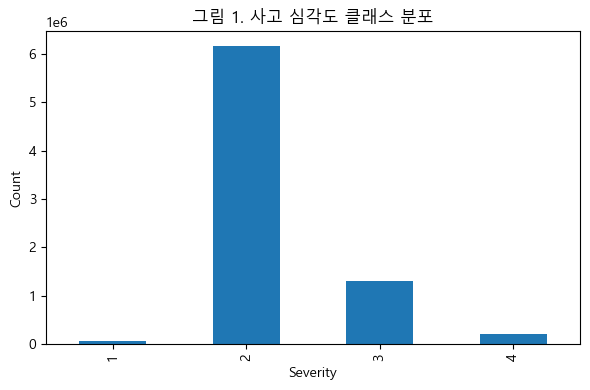

In [9]:
severity_count = df["Severity"].value_counts().sort_index()
severity_ratio = df["Severity"].value_counts(normalize=True).sort_index()

severity_df = pd.DataFrame({
    "count": severity_count,
    "ratio": severity_ratio
})

print("표 1. 원본 데이터의 Severity 클래스별 건수와 비율")
display(severity_df)

plt.figure(figsize=(6, 4))
severity_count.plot(kind="bar")
plt.title("그림 1. 사고 심각도 클래스 분포")
plt.xlabel("Severity")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("figures/fig01_severity_distribution.png", dpi=200)
plt.show()

## 7. 층화 샘플링

원본 데이터가 매우 크기 때문에 일부 표본을 사용한다.  
단순 랜덤 샘플링을 하면 클래스 비율이 달라질 수 있으므로, `stratify=df["Severity"]`를 사용하여 Severity 비율을 유지한다.

샘플링 후 데이터 크기: (100000, 34)
표 2. 원본 데이터와 샘플 데이터의 Severity 비율 비교


,original_ratio,sample_ratio
Severity,,
1,0.008717,0.00872
2,0.796670,0.79667
3,0.168125,0.16812
4,0.026488,0.02649


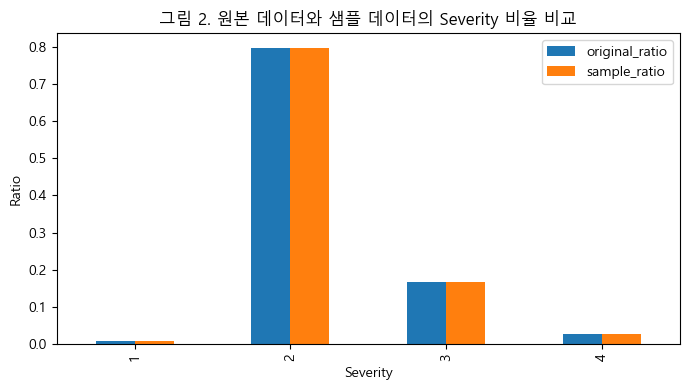

In [10]:
if len(df) > SAMPLE_SIZE:
    sampled_df, _ = train_test_split(
        df,
        train_size=SAMPLE_SIZE,
        random_state=RANDOM_STATE,
        stratify=df["Severity"]
    )
else:
    sampled_df = df.copy()

sampled_df = sampled_df.reset_index(drop=True)

print("샘플링 후 데이터 크기:", sampled_df.shape)

sample_ratio_df = pd.DataFrame({
    "original_ratio": df["Severity"].value_counts(normalize=True).sort_index(),
    "sample_ratio": sampled_df["Severity"].value_counts(normalize=True).sort_index()
})

print("표 2. 원본 데이터와 샘플 데이터의 Severity 비율 비교")
display(sample_ratio_df)

sample_ratio_df.plot(kind="bar", figsize=(7, 4))
plt.title("그림 2. 원본 데이터와 샘플 데이터의 Severity 비율 비교")
plt.xlabel("Severity")
plt.ylabel("Ratio")
plt.tight_layout()
plt.savefig("figures/fig02_original_sample_ratio.png", dpi=200)
plt.show()

## 8. 시간 변수 생성

`Start_Time`에서 연도, 월, 요일, 시간 변수를 생성한다.

In [11]:
data = sampled_df.copy()

# pandas 버전 호환성을 위해 format="mixed"를 사용하지 않고 자동 파싱한다.
data["Start_Time"] = pd.to_datetime(data["Start_Time"], errors="coerce")

data["Month"] = data["Start_Time"].dt.month
data["DayOfWeek"] = data["Start_Time"].dt.dayofweek
data["Hour"] = data["Start_Time"].dt.hour

data = data.drop(columns=["Start_Time"])

display(data[["Month", "DayOfWeek", "Hour"]].head())


,Month,DayOfWeek,Hour
0,2.0,0.0,12.0
1,9.0,4.0,9.0
2,3.0,3.0,16.0
3,9.0,6.0,14.0
4,6.0,5.0,15.0


### 시간 변수 생성

`Start_Time`은 날짜형으로 변환한 뒤 사고 발생 월(`Month`), 요일(`DayOfWeek`), 시간대(`Hour`)를 파생 변수로 생성합니다.  
사고 발생 시점의 계절성, 요일별 교통 특성, 시간대별 교통 흐름 차이를 반영하기 위한 전처리입니다.


## 9. 날씨 변수 단순화

`Weather_Condition`은 세부 범주가 많다.  
차원이 지나치게 커지는 것을 줄이기 위해 비슷한 날씨를 묶어 `Weather_Group` 변수를 생성한다.

In [12]:
def weather_group(x):
    if pd.isna(x):
        return "Unknown"

    x = str(x).lower()

    if "clear" in x or "fair" in x:
        return "Clear"
    elif "cloud" in x or "overcast" in x:
        return "Cloudy"
    elif "rain" in x or "drizzle" in x or "shower" in x:
        return "Rain"
    elif "snow" in x or "sleet" in x or "ice" in x:
        return "Snow"
    elif "fog" in x or "mist" in x or "haze" in x:
        return "Fog"
    elif "storm" in x or "thunder" in x:
        return "Storm"
    else:
        return "Other"


data["Weather_Group"] = data["Weather_Condition"].apply(weather_group)
data = data.drop(columns=["Weather_Condition"])

display(data["Weather_Group"].value_counts())

Weather_Group
Clear      44293
Cloudy     40657
Rain        6948
Fog         2543
Unknown     2272
Snow        2066
Storm        833
Other        388
Name: count, dtype: int64

## 10. 범주가 많은 변수 1차 정리

`City`, `County`는 고유값이 많기 때문에 나중에 상위 범주만 유지한다.  
단, 상위 30개 범주는 전체 데이터가 아니라 **train set 기준**으로 선정해야 validation/test 정보가 전처리 기준에 섞이지 않는다.  
따라서 이 단계에서는 결측치만 `Unknown`으로 채우고, 실제 범주 축소는 train/validation/test 분할 이후에 수행한다.

In [13]:
for col in ["City", "County"]:
    data[col] = data[col].fillna("Unknown")

print("City 원본 고유값 수:", data["City"].nunique())
print("County 원본 고유값 수:", data["County"].nunique())

City 원본 고유값 수: 6430
County 원본 고유값 수: 1286


## 11. 강수량 결측 여부 변수 추가

`Precipitation(in)`은 결측치가 많을 수 있다.  
강수량 값이 결측인지 여부 자체도 의미가 있을 수 있으므로 `Precipitation_NA` 변수를 추가한다.

In [14]:
data["Precipitation_NA"] = data["Precipitation(in)"].isna().astype(int)

display(data[["Precipitation(in)", "Precipitation_NA"]].head())

,Precipitation(in),Precipitation_NA
0,NaN,1
1,0.0,0
2,0.0,0
3,0.0,0
4,0.0,0


## 12. Boolean 변수 변환

도로환경 변수 중 True/False 값으로 되어 있는 변수는 0/1로 변환한다.

In [15]:
bool_cols = data.select_dtypes(include=["bool"]).columns.tolist()

for col in bool_cols:
    data[col] = data[col].astype(int)

print("0/1로 변환한 Boolean 변수:", bool_cols)

0/1로 변환한 Boolean 변수: ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop']


## 13. 결측치 비율 확인

결측치 처리는 train / validation / test 분할 이후에 진행한다.  
이 단계에서는 결측치가 많은 변수를 확인한다.

표 3. 전처리 후 변수별 결측치 비율 상위 20개


Precipitation(in)        0.28598
Wind_Chill(F)            0.25881
Hour                     0.09662
DayOfWeek                0.09662
Month                    0.09662
Wind_Speed(mph)          0.07424
Visibility(mi)           0.02320
Humidity(%)              0.02305
Wind_Direction           0.02286
Temperature(F)           0.02173
Pressure(in)             0.01876
Astronomical_Twilight    0.00323
Nautical_Twilight        0.00323
Civil_Twilight           0.00323
Sunrise_Sunset           0.00323
Timezone                 0.00092
Turning_Loop             0.00000
Traffic_Signal           0.00000
Traffic_Calming          0.00000
Severity                 0.00000
dtype: float64

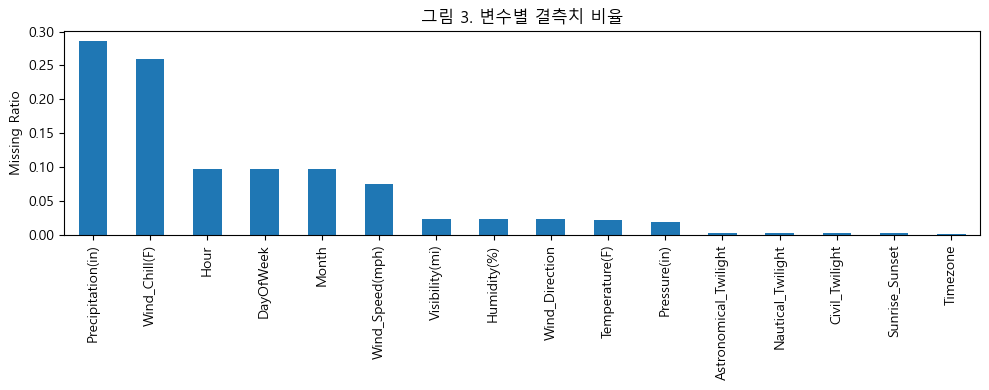

In [16]:
missing_ratio = data.isnull().mean().sort_values(ascending=False)

print("표 3. 전처리 후 변수별 결측치 비율 상위 20개")
display(missing_ratio.head(20))

plt.figure(figsize=(10, 4))
missing_ratio[missing_ratio > 0].plot(kind="bar")
plt.title("그림 3. 변수별 결측치 비율")
plt.ylabel("Missing Ratio")
plt.tight_layout()
plt.savefig("figures/fig03_missing_ratio.png", dpi=200)
plt.show()

## 14. 탐색적 데이터 분석(EDA)

과제 요구사항에 맞추어 8개 이상의 그래프를 포함한다.  
아래 그래프들은 사고 시간, 월, 날씨, 신호등, 교차부, 가시거리, 지역 분포, 도로환경 변수의 특성을 확인하기 위한 것이다.

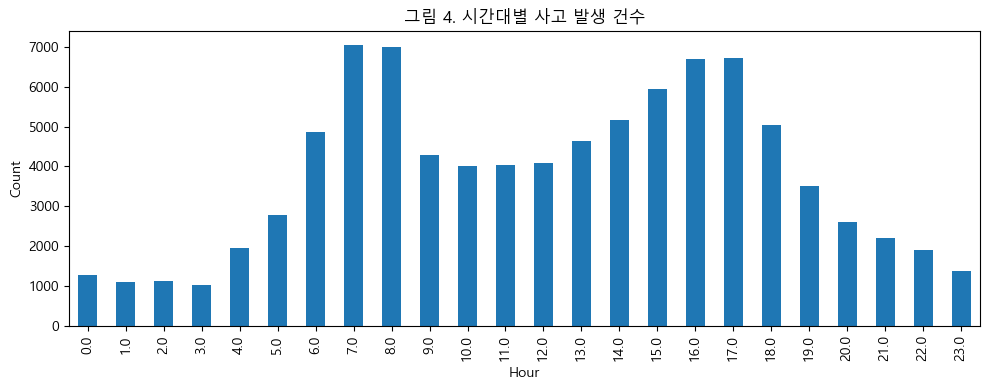

In [17]:
plt.figure(figsize=(10, 4))
data["Hour"].value_counts().sort_index().plot(kind="bar")
plt.title("그림 4. 시간대별 사고 발생 건수")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("figures/fig04_accidents_by_hour.png", dpi=200)
plt.show()

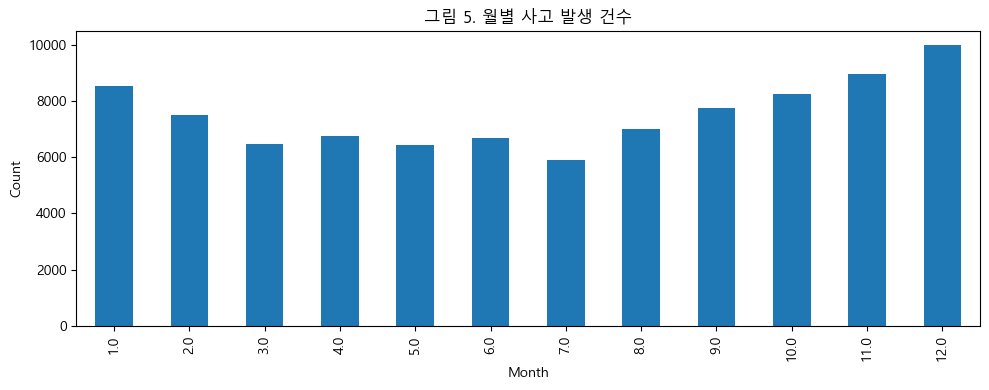

In [18]:
plt.figure(figsize=(10, 4))
data["Month"].value_counts().sort_index().plot(kind="bar")
plt.title("그림 5. 월별 사고 발생 건수")
plt.xlabel("Month")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("figures/fig05_accidents_by_month.png", dpi=200)
plt.show()

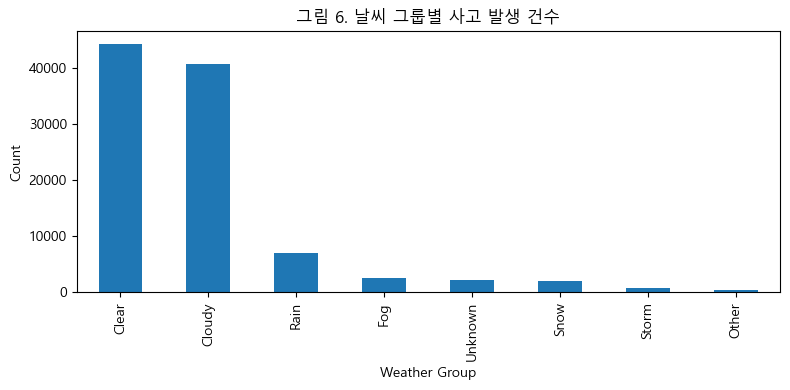

In [19]:
plt.figure(figsize=(8, 4))
data["Weather_Group"].value_counts().plot(kind="bar")
plt.title("그림 6. 날씨 그룹별 사고 발생 건수")
plt.xlabel("Weather Group")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("figures/fig06_accidents_by_weather.png", dpi=200)
plt.show()

표 4. 날씨 그룹별 Severity 비율


Severity,1,2,3,4
Weather_Group,,,,
Clear,0.010814,0.819317,0.144425,0.025444
Cloudy,0.008018,0.774602,0.191578,0.025801
Fog,0.002359,0.839953,0.137633,0.020055
Other,0.000000,0.845361,0.113402,0.041237
Rain,0.005901,0.763817,0.202073,0.028210
Snow,0.000484,0.799129,0.154889,0.045499
Storm,0.015606,0.817527,0.145258,0.021609
Unknown,0.002641,0.783891,0.170335,0.043134


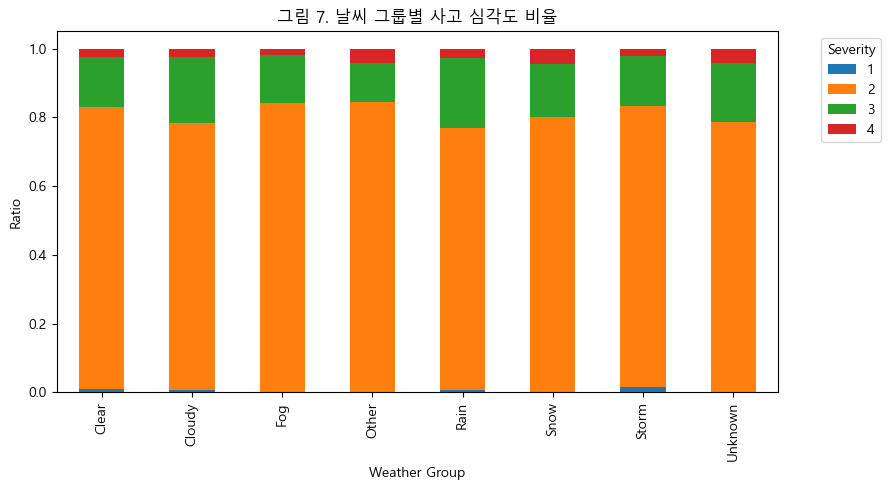

In [20]:
weather_severity = pd.crosstab(data["Weather_Group"], data["Severity"], normalize="index")
print("표 4. 날씨 그룹별 Severity 비율")
display(weather_severity)

weather_severity.plot(kind="bar", stacked=True, figsize=(9, 5))
plt.title("그림 7. 날씨 그룹별 사고 심각도 비율")
plt.xlabel("Weather Group")
plt.ylabel("Ratio")
plt.legend(title="Severity", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("figures/fig07_weather_severity_ratio.png", dpi=200)
plt.show()

표 5. 신호등 여부별 Severity 비율


Severity,1,2,3,4
Traffic_Signal,,,,
0,0.006347,0.781893,0.183909,0.027851
1,0.022422,0.881994,0.076954,0.018629


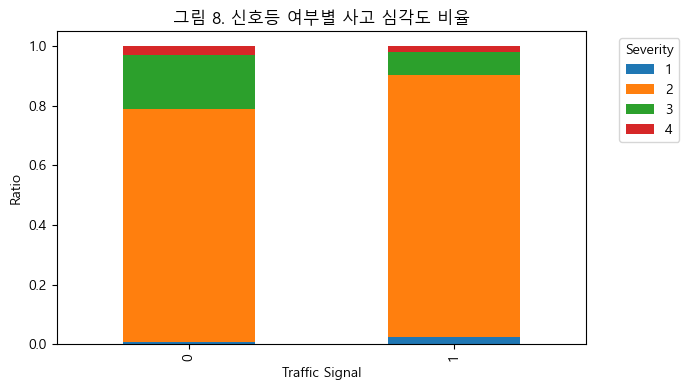

In [21]:
signal_severity = pd.crosstab(data["Traffic_Signal"], data["Severity"], normalize="index")
print("표 5. 신호등 여부별 Severity 비율")
display(signal_severity)

signal_severity.plot(kind="bar", stacked=True, figsize=(7, 4))
plt.title("그림 8. 신호등 여부별 사고 심각도 비율")
plt.xlabel("Traffic Signal")
plt.ylabel("Ratio")
plt.legend(title="Severity", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("figures/fig08_signal_severity_ratio.png", dpi=200)
plt.show()

표 6. 교차부 여부별 Severity 비율


Severity,1,2,3,4
Junction,,,,
0,0.009026,0.801663,0.163399,0.025912
1,0.004878,0.734011,0.227371,0.033740


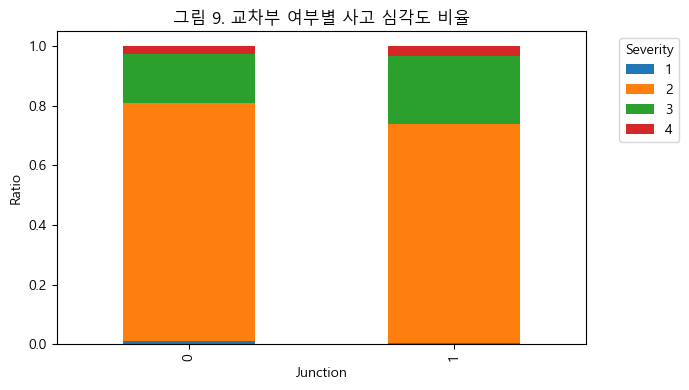

In [22]:
junction_severity = pd.crosstab(data["Junction"], data["Severity"], normalize="index")
print("표 6. 교차부 여부별 Severity 비율")
display(junction_severity)

junction_severity.plot(kind="bar", stacked=True, figsize=(7, 4))
plt.title("그림 9. 교차부 여부별 사고 심각도 비율")
plt.xlabel("Junction")
plt.ylabel("Ratio")
plt.legend(title="Severity", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("figures/fig09_junction_severity_ratio.png", dpi=200)
plt.show()

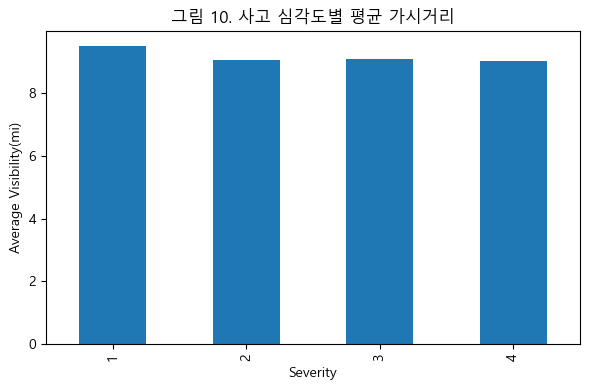

In [23]:
plt.figure(figsize=(6, 4))
data.groupby("Severity")["Visibility(mi)"].mean().plot(kind="bar")
plt.title("그림 10. 사고 심각도별 평균 가시거리")
plt.xlabel("Severity")
plt.ylabel("Average Visibility(mi)")
plt.tight_layout()
plt.savefig("figures/fig10_visibility_by_severity.png", dpi=200)
plt.show()

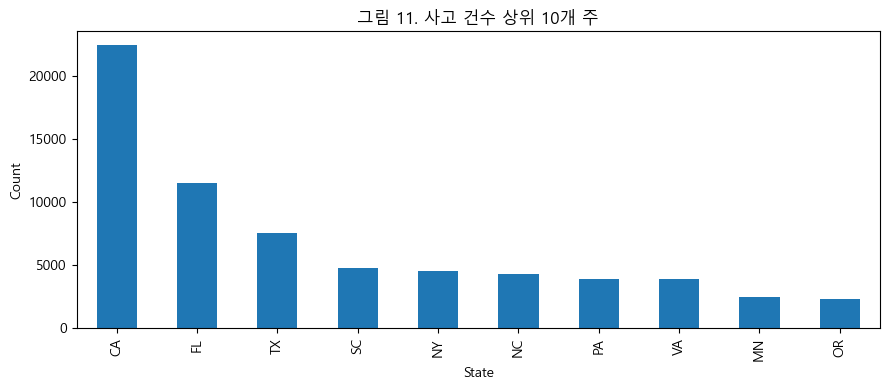

In [24]:
plt.figure(figsize=(9, 4))
data["State"].value_counts().head(10).plot(kind="bar")
plt.title("그림 11. 사고 건수 상위 10개 주")
plt.xlabel("State")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("figures/fig11_top10_states.png", dpi=200)
plt.show()

표 7. 도로환경 변수별 True 비율


Traffic_Signal     0.14762
Crossing           0.11293
Junction           0.07380
Stop               0.02792
Station            0.02593
Amenity            0.01261
Railway            0.00855
Give_Way           0.00502
No_Exit            0.00270
Traffic_Calming    0.00090
Bump               0.00035
Roundabout         0.00002
Turning_Loop       0.00000
dtype: float64

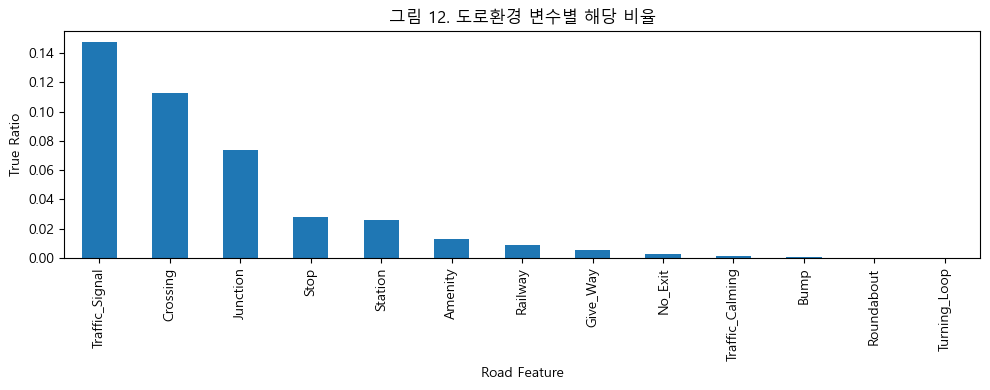

In [25]:
road_cols = [
    "Amenity", "Bump", "Crossing", "Give_Way", "Junction",
    "No_Exit", "Railway", "Roundabout", "Station", "Stop",
    "Traffic_Calming", "Traffic_Signal", "Turning_Loop"
]

road_ratio = data[road_cols].mean().sort_values(ascending=False)
print("표 7. 도로환경 변수별 True 비율")
display(road_ratio)

plt.figure(figsize=(10, 4))
road_ratio.plot(kind="bar")
plt.title("그림 12. 도로환경 변수별 해당 비율")
plt.xlabel("Road Feature")
plt.ylabel("True Ratio")
plt.tight_layout()
plt.savefig("figures/fig12_road_feature_ratio.png", dpi=200)
plt.show()

## 15. 미국 교통사고 위치 분포 시각화 (Severity 1~4)
미국 전역의 교통사고 위치를 Severity 1, 2, 3, 4별로 구분하여 시각화한다.  
첫 번째 그림은 전체 샘플 데이터를 그대로 사용하고,  
두 번째 그림은 클래스별 최대 표본 수를 맞춰 시각적 비교가 더 잘 되도록 구성한다.

지도 시각화에 사용되는 데이터 크기: (100000, 34)


,Start_Lat,Start_Lng,Severity
0,29.681866,-95.249031,2
1,38.963650,-77.183487,3
2,45.530380,-122.637530,2
3,47.821847,-122.277882,2
4,33.538550,-112.116940,1


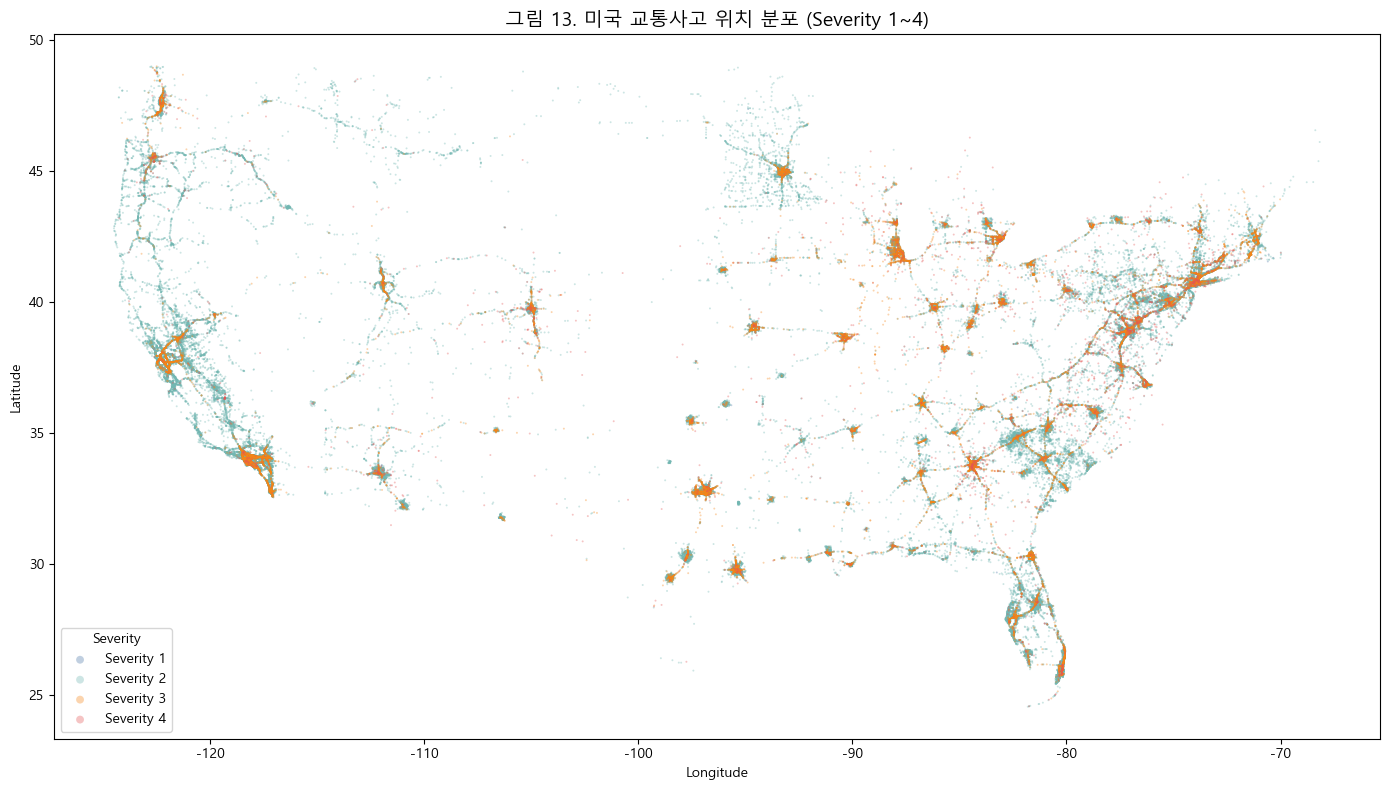

균형 시각화용 데이터 크기: (13521, 34)


Severity
1     872
2    5000
3    5000
4    2649
Name: count, dtype: int64

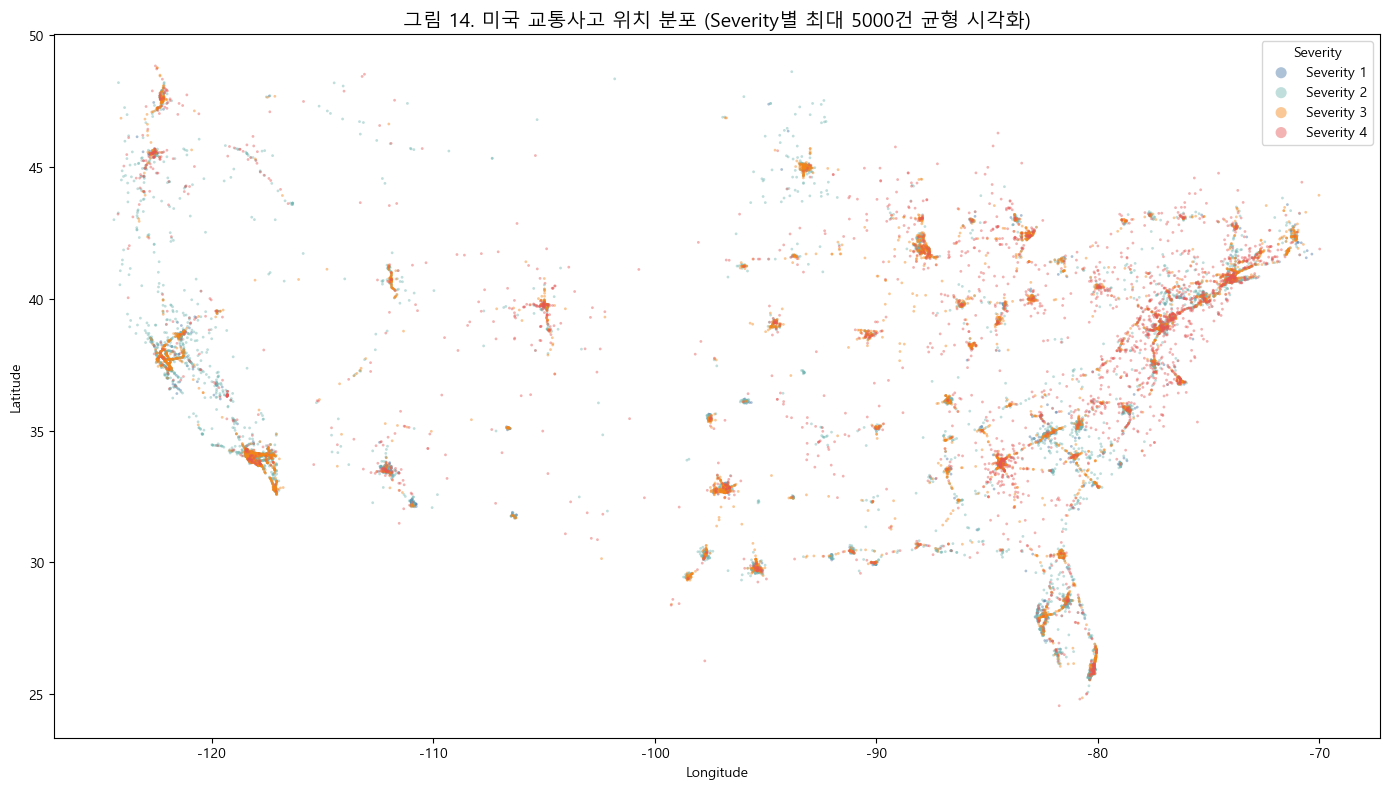

In [26]:
# =========================
# 15. 미국 교통사고 위치 분포 시각화 (Severity 1~4)
# =========================

# 사용할 데이터 선택
# sampled_df 또는 data 중 Start_Lat, Start_Lng, Severity가 있는 것을 사용
map_df = sampled_df.copy()

# 위도/경도 결측 제거
map_df = map_df.dropna(subset=["Start_Lat", "Start_Lng", "Severity"]).copy()

print("지도 시각화에 사용되는 데이터 크기:", map_df.shape)
display(map_df[["Start_Lat", "Start_Lng", "Severity"]].head())

# Severity 색상 설정
severity_colors = {
    1: "#4C78A8",   # blue
    2: "#72B7B2",   # teal
    3: "#F58518",   # orange
    4: "#E45756"    # red
}

# -------------------------
# 그림 13. Severity 1~4 전체 위치 분포
# -------------------------
plt.figure(figsize=(14, 8))

for sev in [1, 2, 3, 4]:
    subset = map_df[map_df["Severity"] == sev]
    plt.scatter(
        subset["Start_Lng"],
        subset["Start_Lat"],
        s=2,
        alpha=0.35,
        c=severity_colors[sev],
        label=f"Severity {sev}",
        edgecolors="none"
    )

plt.title("그림 13. 미국 교통사고 위치 분포 (Severity 1~4)", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Severity", markerscale=4)
plt.tight_layout()
plt.savefig("figures/fig13_us_accidents_severity_map.png", dpi=200)
plt.show()

# -------------------------
# 그림 14. Severity별 표본 수를 맞춘 위치 분포
# -------------------------
# Severity 2가 너무 많아 다른 클래스가 묻히는 것을 방지하기 위해
# 클래스별 최대 5000개씩만 추출하여 비교용 시각화를 생성
max_points_per_class = 5000

balanced_map_df = (
    map_df.groupby("Severity", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), max_points_per_class), random_state=RANDOM_STATE))
    .reset_index(drop=True)
)

print("균형 시각화용 데이터 크기:", balanced_map_df.shape)
display(balanced_map_df["Severity"].value_counts().sort_index())

plt.figure(figsize=(14, 8))

for sev in [1, 2, 3, 4]:
    subset = balanced_map_df[balanced_map_df["Severity"] == sev]
    plt.scatter(
        subset["Start_Lng"],
        subset["Start_Lat"],
        s=4,
        alpha=0.45,
        c=severity_colors[sev],
        label=f"Severity {sev}",
        edgecolors="none"
    )

plt.title("그림 14. 미국 교통사고 위치 분포 (Severity별 최대 5000건 균형 시각화)", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Severity", markerscale=4)
plt.tight_layout()
plt.savefig("figures/fig14_us_accidents_severity_map_balanced.png", dpi=200)
plt.show()

## 15. 입력 데이터와 타깃 데이터 분리

`Severity`는 예측 대상이므로 타깃 데이터로 분리하고, 나머지 변수는 입력 데이터로 사용한다.

In [27]:
input_data = data.drop(columns=["Severity"])
target = data["Severity"]

print("입력 데이터 크기:", input_data.shape)
print("타깃 데이터 크기:", target.shape)
display(target.value_counts(normalize=True).sort_index())

입력 데이터 크기: (100000, 36)
타깃 데이터 크기: (100000,)


Severity
1    0.00872
2    0.79667
3    0.16812
4    0.02649
Name: proportion, dtype: float64

## 16. Train / Validation / Test 분할

모든 모델은 동일한 데이터 분할을 사용한다.

- Train: 모델 학습
- Validation: 모델 비교 및 선택
- Test: 최종 평가

클래스 비율 유지를 위해 `stratify`를 적용한다.

In [28]:
train_input, test_input, train_target, test_target = train_test_split(
    input_data,
    target,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=target
)

train_input, val_input, train_target, val_target = train_test_split(
    train_input,
    train_target,
    test_size=0.1765,
    random_state=RANDOM_STATE,
    stratify=train_target
)

print("train:", train_input.shape, train_target.shape)
print("validation:", val_input.shape, val_target.shape)
print("test:", test_input.shape, test_target.shape)

split_ratio = pd.DataFrame({
    "train": train_target.value_counts(normalize=True).sort_index(),
    "validation": val_target.value_counts(normalize=True).sort_index(),
    "test": test_target.value_counts(normalize=True).sort_index()
})

print("표 8. 데이터 분할별 Severity 비율")
display(split_ratio)

train: (69997, 36) (69997,)
validation: (15003, 36) (15003,)
test: (15000, 36) (15000,)
표 8. 데이터 분할별 Severity 비율


,train,validation,test
Severity,,,
1,0.008715,0.008732,0.008733
2,0.796677,0.796641,0.796667
3,0.168121,0.168100,0.168133
4,0.026487,0.026528,0.026467


## 17. Train 기준 범주 축소

`City`, `County`처럼 고유값이 많은 범주형 변수는 train set 기준 상위 30개만 유지하고 나머지는 `Other`로 통합한다.  
Validation/test에는 train set에서 정한 기준을 그대로 적용한다.

In [29]:
train_input = train_input.copy()
val_input = val_input.copy()
test_input = test_input.copy()

high_cardinality_cols = ["City", "County"]
top_category_dict = {}

for col in high_cardinality_cols:
    top_values = train_input[col].value_counts().head(30).index
    top_category_dict[col] = set(top_values)

    train_input[col] = train_input[col].where(train_input[col].isin(top_category_dict[col]), "Other")
    val_input[col] = val_input[col].where(val_input[col].isin(top_category_dict[col]), "Other")
    test_input[col] = test_input[col].where(test_input[col].isin(top_category_dict[col]), "Other")

print("Train 기준 범주 축소 후 고유값 수")
for col in high_cardinality_cols:
    print(f"{col}: train={train_input[col].nunique()}, val={val_input[col].nunique()}, test={test_input[col].nunique()}")

Train 기준 범주 축소 후 고유값 수
City: train=31, val=31, test=31
County: train=31, val=31, test=31


## 18. 결측치 처리

결측치는 훈련 세트 기준으로 처리한다.

- 수치형 변수: 훈련 세트의 중앙값으로 대체
- 범주형 변수: 훈련 세트의 최빈값으로 대체

검증 세트와 테스트 세트에는 훈련 세트에서 계산한 값을 그대로 적용한다.

In [30]:
num_cols = train_input.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = train_input.select_dtypes(include=["object"]).columns.tolist()

print("수치형 변수 수:", len(num_cols))
print("범주형 변수 수:", len(cat_cols))

if num_cols:
    num_median = train_input[num_cols].median()
    train_input[num_cols] = train_input[num_cols].fillna(num_median)
    val_input[num_cols] = val_input[num_cols].fillna(num_median)
    test_input[num_cols] = test_input[num_cols].fillna(num_median)
else:
    num_median = pd.Series(dtype=float)

if cat_cols:
    cat_mode = train_input[cat_cols].mode().iloc[0]
    train_input[cat_cols] = train_input[cat_cols].fillna(cat_mode)
    val_input[cat_cols] = val_input[cat_cols].fillna(cat_mode)
    test_input[cat_cols] = test_input[cat_cols].fillna(cat_mode)
else:
    cat_mode = pd.Series(dtype=object)

print("train 결측치 수:", train_input.isnull().sum().sum())
print("validation 결측치 수:", val_input.isnull().sum().sum())
print("test 결측치 수:", test_input.isnull().sum().sum())

수치형 변수 수: 12
범주형 변수 수: 10
train 결측치 수: 0
validation 결측치 수: 0
test 결측치 수: 0


## 19. 범주형 변수 인코딩

범주형 변수는 문자열 그대로 모델에 입력할 수 없기 때문에 `pd.get_dummies()`로 원-핫 인코딩한다.  
검증 세트와 테스트 세트는 훈련 세트와 동일한 열 구조가 되도록 맞춘다.

In [31]:
train_encoded = pd.get_dummies(train_input, columns=cat_cols)
val_encoded = pd.get_dummies(val_input, columns=cat_cols)
test_encoded = pd.get_dummies(test_input, columns=cat_cols)

val_encoded = val_encoded.reindex(columns=train_encoded.columns, fill_value=0)
test_encoded = test_encoded.reindex(columns=train_encoded.columns, fill_value=0)

# sklearn 모델 입력을 위해 bool dummy column을 0/1 정수로 변환한다.
train_encoded = train_encoded.astype({col: "int8" for col in train_encoded.select_dtypes(include=["bool"]).columns})
val_encoded = val_encoded.astype({col: "int8" for col in val_encoded.select_dtypes(include=["bool"]).columns})
test_encoded = test_encoded.astype({col: "int8" for col in test_encoded.select_dtypes(include=["bool"]).columns})

print("train_encoded:", train_encoded.shape)
print("val_encoded:", val_encoded.shape)
print("test_encoded:", test_encoded.shape)

train_encoded: (69997, 181)
val_encoded: (15003, 181)
test_encoded: (15000, 181)


## 20. 표준화

로지스틱 회귀와 신경망은 변수의 스케일 영향을 받을 수 있으므로 연속형 수치 변수에 `StandardScaler`를 적용한다.  
단, `Amenity`, `Junction`, `Traffic_Signal`, `Precipitation_NA`처럼 0/1 값만 가지는 이진 변수는 해석성을 위해 표준화하지 않는다.

In [32]:
scaler = StandardScaler()

train_scaled = train_encoded.copy()
val_scaled = val_encoded.copy()
test_scaled = test_encoded.copy()

# 원래 수치형 변수 중 값 종류가 3개 이상인 변수만 연속형으로 보고 표준화한다.
scale_cols = [
    col for col in num_cols
    if col in train_scaled.columns and train_input[col].nunique(dropna=True) > 2
]
binary_num_cols = [col for col in num_cols if col not in scale_cols]

print("표준화 적용 변수 수:", len(scale_cols))
print("표준화 제외 0/1 또는 저유니크 수치 변수 수:", len(binary_num_cols))

if scale_cols:
    scaler.fit(train_scaled[scale_cols])
    train_scaled[scale_cols] = scaler.transform(train_scaled[scale_cols])
    val_scaled[scale_cols] = scaler.transform(val_scaled[scale_cols])
    test_scaled[scale_cols] = scaler.transform(test_scaled[scale_cols])

display(train_scaled.head())

표준화 적용 변수 수: 12
표준화 제외 0/1 또는 저유니크 수치 변수 수: 0


,Start_Lat,Start_Lng,Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in),Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Month,DayOfWeek,Hour,Precipitation_NA,City_Atlanta,City_Austin,City_Baton Rouge,City_Charlotte,City_Chicago,City_Columbia,City_Dallas,City_Denver,City_Fort Lauderdale,City_Greenville,City_Houston,City_Indianapolis,City_Jacksonville,City_Los Angeles,City_Miami,City_Minneapolis,City_Nashville,City_Oklahoma City,City_Orlando,City_Other,City_Phoenix,City_Portland,City_Raleigh,City_Richmond,City_Sacramento,City_Saint Paul,City_San Antonio,City_San Diego,City_San Jose,City_Seattle,City_Tucson,County_Alameda,County_Broward,County_Contra Costa,...,State_OH,State_OK,State_OR,State_PA,State_RI,State_SC,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY,Timezone_US/Central,Timezone_US/Eastern,Timezone_US/Mountain,Timezone_US/Pacific,Wind_Direction_CALM,Wind_Direction_Calm,Wind_Direction_E,Wind_Direction_ENE,Wind_Direction_ESE,Wind_Direction_East,Wind_Direction_N,Wind_Direction_NE,Wind_Direction_NNE,Wind_Direction_NNW,Wind_Direction_NW,Wind_Direction_North,Wind_Direction_S,Wind_Direction_SE,Wind_Direction_SSE,Wind_Direction_SSW,Wind_Direction_SW,Wind_Direction_South,Wind_Direction_VAR,Wind_Direction_Variable,Wind_Direction_W,Wind_Direction_WNW,Wind_Direction_WSW,Wind_Direction_West,Sunrise_Sunset_Day,Sunrise_Sunset_Night,Civil_Twilight_Day,Civil_Twilight_Night,Nautical_Twilight_Day,Nautical_Twilight_Night,Astronomical_Twilight_Day,Astronomical_Twilight_Night,Weather_Group_Clear,Weather_Group_Cloudy,Weather_Group_Fog,Weather_Group_Other,Weather_Group_Rain,Weather_Group_Snow,Weather_Group_Storm,Weather_Group_Unknown
92443,0.547090,-1.605585,-0.412499,-0.271223,0.804758,-0.089914,0.331431,-0.518517,-0.067445,0,0,0,0,0,0,0,0,0,0,0,0,0,1.512587,0.814167,0.897313,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,1,0,1,0,0,0,0,0,0,0
29333,0.513693,-0.582029,-1.639621,-1.706734,0.316933,0.732608,0.331431,-0.596890,-0.067445,0,0,0,0,0,0,0,0,0,0,0,0,0,0.932708,-1.525894,0.128584,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,1,0,1,0,0,0,0,0,0,1,0,0
87792,-0.534955,-1.000920,0.915555,1.019705,-2.210888,-0.823248,0.331431,-0.322584,-0.067445,0,0,0,0,0,0,0,0,0,0,0,0,0,-0.516988,0.814167,-0.832328,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,1,0,1,0,0,0,0,0,0,0
74620,-0.665896,-0.116431,1.553021,1.639350,-0.570022,0.048824,0.331431,-1.498178,-0.067445,0,0,0,0,0,0,0,0,0,0,0,0,0,0.062891,0.229152,0.128584,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,1,0,1,0,0,0,0,0,0,0
8647,-0.339640,-1.458816,-1.209331,0.141874,0.937801,0.683059,0.331431,-0.126652,-0.067445,0,0,0,0,1,0,0,0,0,0,0,0,0,-1.096866,-0.355863,-1.601057,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,1,1,0,0,0,0,0,0,0


## 21. 평가 함수와 후보 모델 등록 함수 정의

본 데이터는 `Severity=2`가 많은 클래스 불균형 데이터이다.  
따라서 Accuracy만 사용하지 않고 `balanced_accuracy`, `macro_f1`, `weighted_f1` 등을 함께 계산한다.

최종 모델은 Validation set의 **Macro F1-score**를 기준으로 선택한다.  
Macro F1은 각 Severity 클래스의 F1-score를 동일한 비중으로 평균내므로, 다수 클래스에만 유리한 모델을 방지하는 데 적합하다.

In [33]:
def get_scores(model_name, y_true, y_pred):
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }


candidate_models = {}
candidate_val_results = []
model_label_offset = {}


def register_model(model_name, model, val_pred, val_score, label_offset=0):
    """학습된 모델과 Validation 결과를 최종 후보 목록에 등록한다."""
    candidate_models[model_name] = model
    candidate_val_results.append(val_score)
    model_label_offset[model_name] = label_offset


def fit_and_eval(model, model_name, sample_weight=None, y_train=None, label_offset=0):
    """모델 학습, Validation 예측, 성능 계산, 후보 등록을 한 번에 수행한다."""
    if y_train is None:
        y_train = train_target

    if sample_weight is None:
        model.fit(train_scaled, y_train)
    else:
        model.fit(train_scaled, y_train, sample_weight=sample_weight)

    pred = model.predict(val_scaled)
    if label_offset != 0:
        pred = pred + label_offset

    score = get_scores(model_name, val_target, pred)
    register_model(model_name, model, pred, score, label_offset=label_offset)
    return model, pred, score


def show_result(title, result):
    print(title)
    display(pd.DataFrame([result]))

## 22. 기본 모델 및 클래스 불균형 대응 모델 학습

기본 모델과 불균형 대응 모델을 동일한 train/validation set에서 학습하고 비교한다.  
불균형 대응은 `class_weight`, `balanced_subsample`, `sample_weight` 방식으로 적용한다.

In [34]:
# 1) Baseline: 가장 많은 클래스만 예측

dummy = DummyClassifier(strategy="most_frequent")
dummy, dummy_pred, dummy_result = fit_and_eval(dummy, "Dummy")
show_result("표 9. Dummy 모델 Validation 결과", dummy_result)

# 2) Logistic Regression 기본 / balanced
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)
lr, lr_pred, lr_result = fit_and_eval(lr, "Logistic Regression")
show_result("표 10. Logistic Regression Validation 결과", lr_result)

lr_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
lr_balanced, lr_balanced_pred, lr_balanced_result = fit_and_eval(
    lr_balanced,
    "Logistic Regression Balanced"
)
show_result("표 11. Logistic Regression Balanced Validation 결과", lr_balanced_result)

# 3) Decision Tree 기본 / balanced
dt = DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE)
dt, dt_pred, dt_result = fit_and_eval(dt, "Decision Tree")
show_result("표 12. Decision Tree Validation 결과", dt_result)

dt_balanced = DecisionTreeClassifier(
    max_depth=10,
    class_weight="balanced",
    random_state=RANDOM_STATE
)
dt_balanced, dt_balanced_pred, dt_balanced_result = fit_and_eval(
    dt_balanced,
    "Decision Tree Balanced"
)
show_result("표 13. Decision Tree Balanced Validation 결과", dt_balanced_result)

# 4) Random Forest 기본 / balanced_subsample
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf, rf_pred, rf_result = fit_and_eval(rf, "Random Forest")
show_result("표 14. Random Forest Validation 결과", rf_result)

rf_balanced = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_leaf=3,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_balanced, rf_balanced_pred, rf_balanced_result = fit_and_eval(
    rf_balanced,
    "Random Forest Balanced"
)
show_result("표 15. Random Forest Balanced Validation 결과", rf_balanced_result)

# 5) HistGradientBoosting 기본 / sample_weight 적용
hgb = HistGradientBoostingClassifier(
    max_iter=100,
    learning_rate=0.1,
    max_leaf_nodes=31,
    random_state=RANDOM_STATE
)
hgb, hgb_pred, hgb_result = fit_and_eval(hgb, "HistGradientBoosting")
show_result("표 16. HistGradientBoosting Validation 결과", hgb_result)

sample_weight_balanced = compute_sample_weight(class_weight="balanced", y=train_target)
hgb_weighted = HistGradientBoostingClassifier(
    max_iter=100,
    learning_rate=0.1,
    max_leaf_nodes=31,
    random_state=RANDOM_STATE
)
hgb_weighted, hgb_weighted_pred, hgb_weighted_result = fit_and_eval(
    hgb_weighted,
    "HistGradientBoosting Weighted",
    sample_weight=sample_weight_balanced
)
show_result("표 17. HistGradientBoosting Weighted Validation 결과", hgb_weighted_result)

표 9. Dummy 모델 Validation 결과


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,Dummy,0.796641,0.25,0.19916,0.25,0.221703,0.70647


표 10. Logistic Regression Validation 결과


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,Logistic Regression,0.802106,0.278132,0.464597,0.278132,0.276101,0.743301


표 11. Logistic Regression Balanced Validation 결과


...

,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,Random Forest Balanced,0.78091,0.381009,0.418601,0.381009,0.391259,0.775081


표 16. HistGradientBoosting Validation 결과


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,HistGradientBoosting,0.813371,0.316276,0.502897,0.316276,0.334481,0.769054


표 17. HistGradientBoosting Weighted Validation 결과


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,HistGradientBoosting Weighted,0.532494,0.596934,0.360027,0.596934,0.342446,0.611468


## 23. XGBoost / LightGBM 추가 후보 모델

최적 모델 선정을 강화하기 위해 XGBoost와 LightGBM을 추가 후보로 실험한다.  
패키지가 설치되어 있지 않은 환경에서는 해당 셀을 건너뛰도록 `try-except`로 처리하였다.

In [35]:
# XGBoost는 일부 버전에서 클래스 라벨이 0부터 시작해야 하므로 Severity 1~4를 0~3으로 변환하여 학습한다.
try:
    from xgboost import XGBClassifier

    y_train_xgb = train_target.values - 1
    xgb_sample_weight = compute_sample_weight(class_weight="balanced", y=y_train_xgb)

    xgb_model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softmax",
        num_class=4,
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    xgb_model, xgb_pred, xgb_result = fit_and_eval(
        xgb_model,
        "XGBoost Weighted",
        sample_weight=xgb_sample_weight,
        y_train=y_train_xgb,
        label_offset=1
    )
    show_result("표 18. XGBoost Weighted Validation 결과", xgb_result)

except Exception as e:
    print("XGBoost 실험을 건너뜁니다. 필요 시 `pip install xgboost` 후 다시 실행하세요.")
    print(e)


try:
    from lightgbm import LGBMClassifier

    lgbm_model = LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=31,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    )

    lgbm_model, lgbm_pred, lgbm_result = fit_and_eval(
        lgbm_model,
        "LightGBM Balanced"
    )
    show_result("표 19. LightGBM Balanced Validation 결과", lgbm_result)

except Exception as e:
    print("LightGBM 실험을 건너뜁니다. 필요 시 `pip install lightgbm` 후 다시 실행하세요.")
    print(e)

표 18. XGBoost Weighted Validation 결과


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,XGBoost Weighted,0.541092,0.608319,0.363631,0.608319,0.348077,0.619631


표 19. LightGBM Balanced Validation 결과


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,LightGBM Balanced,0.568686,0.595932,0.365498,0.595932,0.360116,0.639802


## 24. Random Forest 하이퍼파라미터 실험

Random Forest Balanced 모델의 `max_depth`, `min_samples_leaf` 값을 변경하면서 Validation 성능을 비교한다.  
각 실험 모델도 최종 후보 목록에 등록하여 전체 후보 모델과 함께 비교한다.

표 20. Random Forest max_depth 변화에 따른 Validation 성능


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,RF Balanced max_depth=5,0.316470,0.520084,0.333903,0.520084,0.238943,0.406543
1,RF Balanced max_depth=10,0.487436,0.543381,0.347647,0.543381,0.312147,0.578525
2,RF Balanced max_depth=15,0.635606,0.510766,0.360522,0.510766,0.371030,0.688631
3,RF Balanced max_depth=20,0.729254,0.452043,0.384064,0.452043,0.405475,0.748335
4,RF Balanced max_depth=None,0.780910,0.381009,0.418601,0.381009,0.391259,0.775081


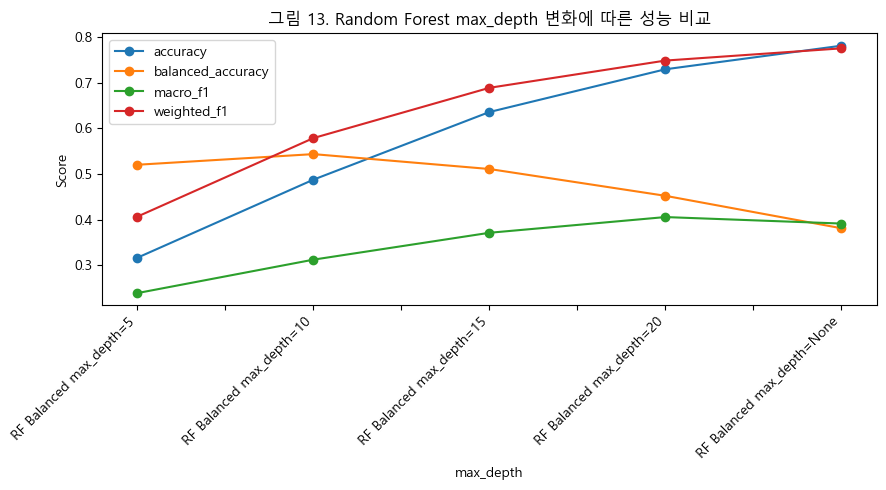

In [36]:
depth_results = []

for depth in [5, 10, 15, 20, None]:
    depth_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        min_samples_leaf=3,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    depth_name = "None" if depth is None else str(depth)
    model_name = f"RF Balanced max_depth={depth_name}"
    depth_model, depth_pred, depth_score = fit_and_eval(depth_model, model_name)
    depth_results.append(depth_score)

depth_df = pd.DataFrame(depth_results)

print("표 20. Random Forest max_depth 변화에 따른 Validation 성능")
display(depth_df)

depth_df.to_csv("outputs/rf_depth_results.csv", index=False)

depth_df.plot(
    x="model",
    y=["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"],
    marker="o",
    figsize=(9, 5)
)
plt.title("그림 13. Random Forest max_depth 변화에 따른 성능 비교")
plt.xlabel("max_depth")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/fig13_rf_depth_comparison.png", dpi=200)
plt.show()

표 21. Random Forest min_samples_leaf 변화에 따른 Validation 성능


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,RF Balanced min_samples_leaf=1,0.805772,0.279989,0.598535,0.279989,0.280272,0.742236
1,RF Balanced min_samples_leaf=3,0.780910,0.381009,0.418601,0.381009,0.391259,0.775081
2,RF Balanced min_samples_leaf=5,0.748117,0.430753,0.396490,0.430753,0.409510,0.758353
3,RF Balanced min_samples_leaf=10,0.680664,0.495244,0.372053,0.495244,0.394732,0.717152


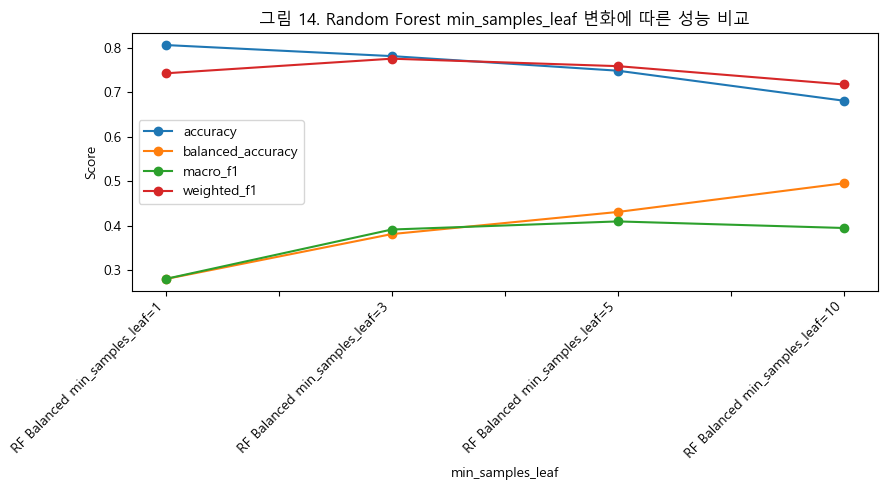

In [37]:
leaf_results = []

for leaf in [1, 3, 5, 10]:
    leaf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        min_samples_leaf=leaf,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model_name = f"RF Balanced min_samples_leaf={leaf}"
    leaf_model, leaf_pred, leaf_score = fit_and_eval(leaf_model, model_name)
    leaf_results.append(leaf_score)

leaf_df = pd.DataFrame(leaf_results)

print("표 21. Random Forest min_samples_leaf 변화에 따른 Validation 성능")
display(leaf_df)

leaf_df.to_csv("outputs/rf_leaf_results.csv", index=False)

leaf_df.plot(
    x="model",
    y=["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"],
    marker="o",
    figsize=(9, 5)
)
plt.title("그림 14. Random Forest min_samples_leaf 변화에 따른 성능 비교")
plt.xlabel("min_samples_leaf")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/fig14_rf_leaf_comparison.png", dpi=200)
plt.show()

## 24-1. 클래스 불균형 추가 처리 실험

본 데이터는 `Severity=2` 클래스 비중이 높게 나타나는 불균형 다중분류 데이터입니다.  
따라서 소수 클래스 예측 성능 개선을 위해 다음 불균형 처리 방법을 추가로 실험합니다.

1. **Undersampling**: 다수 클래스인 `Severity=2`의 학습 샘플 수를 제한한다.
2. **Manual class weight**: `Severity=1`, `3`, `4`에 더 큰 가중치를 부여한다.
3. **RandomOverSampler / SMOTE**: 소수 클래스를 학습 데이터에서만 보강한다.

주의: Validation/Test set에는 샘플링을 적용하지 않고, Train set에만 적용합니다. 그래야 실제 일반화 성능을 공정하게 비교할 수 있습니다.


Train target 분포


,count
Severity,
1,610
2,55765
3,11768
4,1854



Undersampling max_per_class=3000 적용 후 분포


,count
_target,
1,610
2,3000
3,3000
4,1854



Undersampling max_per_class=5000 적용 후 분포


...

,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,RF ManualWeight 2,0.810171,0.32837,0.6433,0.32837,0.344153,0.779317



RF ManualWeight 3 class_weight = {1: 4, 2: 1, 3: 3, 4: 6}


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,RF ManualWeight 3,0.797574,0.352951,0.602349,0.352951,0.358648,0.782223


RandomOverSampler/SMOTE 실험을 건너뜁니다.
필요 시 다음 명령어로 설치 후 다시 실행하세요: pip install imbalanced-learn
No module named 'imblearn'
표 24-1. 클래스 불균형 처리 추가 실험 Validation 성능


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,RF UnderSampling cap=5000,0.694661,0.402263,0.436924,0.402263,0.380355,0.718082
1,RF UnderSampling cap=3000,0.627475,0.454540,0.371074,0.454540,0.375037,0.674403
2,RF ManualWeight 3,0.797574,0.352951,0.602349,0.352951,0.358648,0.782223
3,RF ManualWeight 2,0.810171,0.328370,0.643300,0.328370,0.344153,0.779317
4,RF UnderSampling cap=10000,0.707925,0.373315,0.425345,0.373315,0.337659,0.723891
5,RF ManualWeight 1,0.808572,0.324375,0.718660,0.324375,0.336881,0.777443


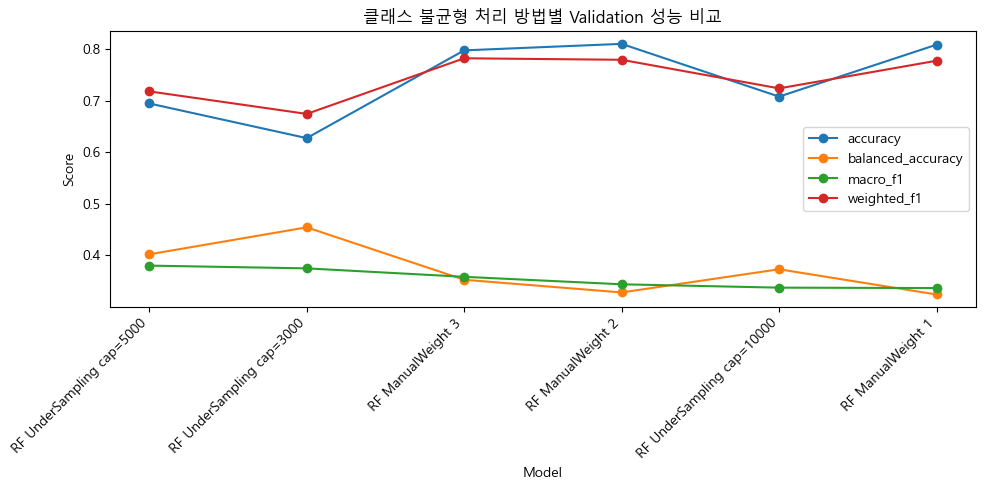

In [38]:
# ===============================
# 클래스 불균형 추가 처리 실험
# ===============================

imbalance_results = []

print("Train target 분포")
display(train_target.value_counts().sort_index().to_frame("count"))


def fit_and_eval_custom_train(model, model_name, X_train_custom, y_train_custom, label_offset=0):
    """샘플링이 적용된 학습 데이터로 모델을 학습하고 기존 Validation set에서 평가한다."""
    model.fit(X_train_custom, y_train_custom)

    pred = model.predict(val_scaled)
    if label_offset != 0:
        pred = pred + label_offset

    score = get_scores(model_name, val_target, pred)
    register_model(model_name, model, pred, score, label_offset=label_offset)
    return model, pred, score


def make_under_sample(X, y, max_per_class, random_state=RANDOM_STATE):
    """각 클래스별 학습 샘플 수를 max_per_class 이하로 제한한다."""
    temp = X.copy()
    temp["_target"] = y.values

    sampled_parts = []
    for cls, group in temp.groupby("_target"):
        n = min(len(group), max_per_class)
        sampled_parts.append(group.sample(n=n, random_state=random_state))

    sampled = pd.concat(sampled_parts, axis=0)
    sampled = sampled.sample(frac=1, random_state=random_state).reset_index(drop=True)

    y_sampled = sampled["_target"].astype(int)
    X_sampled = sampled.drop(columns=["_target"])
    return X_sampled, y_sampled


# -------------------------------------------------
# 1) Undersampling 실험
# -------------------------------------------------
# Severity 2가 압도적으로 많을 경우, 다수 클래스 일부를 줄여 macro F1 개선 여부를 확인한다.
for cap in [3000, 5000, 10000]:
    X_under, y_under = make_under_sample(train_scaled, train_target, max_per_class=cap)

    print(f"\nUndersampling max_per_class={cap} 적용 후 분포")
    display(y_under.value_counts().sort_index().to_frame("count"))

    under_model = RandomForestClassifier(
        n_estimators=150,
        max_depth=None,
        min_samples_leaf=5,
        class_weight=None,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model_name = f"RF UnderSampling cap={cap}"
    under_model, under_pred, under_score = fit_and_eval_custom_train(
        under_model,
        model_name,
        X_under,
        y_under
    )
    imbalance_results.append(under_score)


# -------------------------------------------------
# 2) Manual class_weight 실험
# -------------------------------------------------
# Severity 4 등 소수 클래스에 더 큰 가중치를 직접 부여한다.
manual_weight_candidates = [
    {1: 2, 2: 1, 3: 2, 4: 4},
    {1: 3, 2: 1, 3: 2, 4: 5},
    {1: 4, 2: 1, 3: 3, 4: 6},
]

for idx, weights in enumerate(manual_weight_candidates, start=1):
    weighted_model = RandomForestClassifier(
        n_estimators=150,
        max_depth=None,
        min_samples_leaf=5,
        class_weight=weights,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model_name = f"RF ManualWeight {idx}"
    weighted_model, weighted_pred, weighted_score = fit_and_eval(
        weighted_model,
        model_name
    )
    imbalance_results.append(weighted_score)
    print(f"\n{model_name} class_weight = {weights}")
    display(pd.DataFrame([weighted_score]))


# -------------------------------------------------
# 3) RandomOverSampler / SMOTE 실험
# -------------------------------------------------
# imbalanced-learn이 설치되어 있지 않으면 자동으로 건너뛴다.
try:
    from imblearn.over_sampling import RandomOverSampler, SMOTE

    # 3-1) RandomOverSampler: 소수 클래스 샘플을 단순 복제하여 균형을 맞춘다.
    ros = RandomOverSampler(random_state=RANDOM_STATE)
    X_ros, y_ros = ros.fit_resample(train_scaled, train_target)

    print("\nRandomOverSampler 적용 후 분포")
    display(pd.Series(y_ros).value_counts().sort_index().to_frame("count"))

    ros_model = RandomForestClassifier(
        n_estimators=150,
        max_depth=None,
        min_samples_leaf=5,
        class_weight=None,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    ros_model, ros_pred, ros_score = fit_and_eval_custom_train(
        ros_model,
        "RF RandomOverSampler",
        X_ros,
        y_ros
    )
    imbalance_results.append(ros_score)
    display(pd.DataFrame([ros_score]))

    # 3-2) SMOTE: 소수 클래스 주변 샘플을 합성한다.
    # One-Hot 변수에 대해서는 합성값이 연속값이 될 수 있으므로 결과 해석에 주의한다.
    smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=3)
    X_smote, y_smote = smote.fit_resample(train_scaled, train_target)

    print("\nSMOTE 적용 후 분포")
    display(pd.Series(y_smote).value_counts().sort_index().to_frame("count"))

    smote_model = RandomForestClassifier(
        n_estimators=150,
        max_depth=None,
        min_samples_leaf=5,
        class_weight=None,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    smote_model, smote_pred, smote_score = fit_and_eval_custom_train(
        smote_model,
        "RF SMOTE",
        X_smote,
        y_smote
    )
    imbalance_results.append(smote_score)
    display(pd.DataFrame([smote_score]))

except Exception as e:
    print("RandomOverSampler/SMOTE 실험을 건너뜁니다.")
    print("필요 시 다음 명령어로 설치 후 다시 실행하세요: pip install imbalanced-learn")
    print(e)


# -------------------------------------------------
# 불균형 처리 실험 결과 요약
# -------------------------------------------------
imbalance_result_df = pd.DataFrame(imbalance_results)
if not imbalance_result_df.empty:
    imbalance_result_df = imbalance_result_df.sort_values(by="macro_f1", ascending=False).reset_index(drop=True)
    print("표 24-1. 클래스 불균형 처리 추가 실험 Validation 성능")
    display(imbalance_result_df)
    imbalance_result_df.to_csv("outputs/imbalance_experiment_results.csv", index=False)

    imbalance_result_df.plot(
        x="model",
        y=["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"],
        marker="o",
        figsize=(10, 5)
    )
    plt.title("클래스 불균형 처리 방법별 Validation 성능 비교")
    plt.xlabel("Model")
    plt.ylabel("Score")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("figures/imbalance_experiment_comparison.png", dpi=200)
    plt.show()


## 25. Simple Dense Neural Network 추가 실험

선택 과제에 해당하는 간단한 딥러닝 모델을 실험한다.  
클래스 불균형을 고려하기 위해 Keras 학습 시 `class_weight`를 적용한다.

Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2850 - loss: 1.2360 - val_accuracy: 0.3266 - val_loss: 1.2679
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3658 - loss: 1.0820 - val_accuracy: 0.3781 - val_loss: 1.2034
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3952 - loss: 1.0345 - val_accuracy: 0.3939 - val_loss: 1.1761
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4080 - loss: 1.0121 - val_accuracy: 0.4057 - val_loss: 1.1606
Epoch 5/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4172 - loss: 0.9929 - val_accuracy: 0.4115 - val_loss: 1.1555
Epoch 6/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4215 - loss: 0.9842 - val_accuracy: 0.4196 - val_loss: 1.1385
Epoch 7/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4318 - loss: 0.9617 - val_accuracy: 0.4265 - val_loss: 1.1334
Epoch 8/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4356 - loss: 0.9524 - val_accuracy: 0.

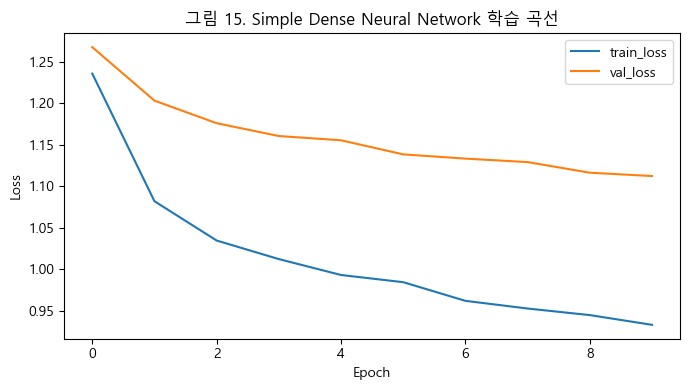

표 22. Simple Dense Neural Network Validation 결과


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,Simple Dense Neural Network,0.440579,0.565262,0.342662,0.565262,0.296571,0.529606


In [39]:
nn_result = None
nn_model = None

try:
    import tensorflow as tf
    from tensorflow import keras

    keras.utils.set_random_seed(RANDOM_STATE)

    y_train_nn = train_target.values - 1
    y_val_nn = val_target.values - 1

    X_train_nn = train_scaled.astype("float32").values
    X_val_nn = val_scaled.astype("float32").values

    nn_class_weights_array = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(y_train_nn),
        y=y_train_nn
    )
    nn_class_weight = {int(cls): float(weight) for cls, weight in zip(np.unique(y_train_nn), nn_class_weights_array)}

    nn_model = keras.Sequential([
        keras.layers.Input(shape=(X_train_nn.shape[1],)),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(4, activation="softmax")
    ])

    nn_model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = nn_model.fit(
        X_train_nn,
        y_train_nn,
        epochs=10,
        batch_size=256,
        validation_data=(X_val_nn, y_val_nn),
        class_weight=nn_class_weight,
        verbose=1
    )

    plt.figure(figsize=(7, 4))
    plt.plot(history.history["loss"], label="train_loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.title("그림 15. Simple Dense Neural Network 학습 곡선")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig("figures/fig15_nn_training_curve.png", dpi=200)
    plt.show()

    nn_val_pred = np.argmax(nn_model.predict(X_val_nn, verbose=0), axis=1) + 1
    nn_result = get_scores("Simple Dense Neural Network", val_target, nn_val_pred)
    register_model("Simple Dense Neural Network", nn_model, nn_val_pred, nn_result)

    print("표 22. Simple Dense Neural Network Validation 결과")
    display(pd.DataFrame([nn_result]))
    pd.DataFrame([nn_result]).to_csv("outputs/nn_validation_result.csv", index=False)

except Exception as e:
    print("Simple Dense Neural Network 실험을 건너뜁니다. TensorFlow 설치 여부를 확인하세요.")
    print(e)

## 26. 전체 후보 모델 Validation 성능 통합 비교

이제 기본 모델, 불균형 대응 모델, XGBoost/LightGBM, Random Forest 하이퍼파라미터 실험, Neural Network 결과를 모두 통합한다.  
최종 모델은 이 통합 결과에서 `macro_f1`이 가장 높은 모델로 선정한다.

표 23. 전체 후보 모델 Validation 성능 통합 비교


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,RF Balanced min_samples_leaf=5,0.748117,0.430753,0.396490,0.430753,0.409510,0.758353
1,RF Balanced max_depth=20,0.729254,0.452043,0.384064,0.452043,0.405475,0.748335
2,RF Balanced min_samples_leaf=10,0.680664,0.495244,0.372053,0.495244,0.394732,0.717152
3,RF Balanced min_samples_leaf=3,0.780910,0.381009,0.418601,0.381009,0.391259,0.775081
4,RF Balanced max_depth=None,0.780910,0.381009,0.418601,0.381009,0.391259,0.775081
5,Random Forest Balanced,0.780910,0.381009,0.418601,0.381009,0.391259,0.775081
6,RF UnderSampling cap=5000,0.694661,0.402263,0.436924,0.402263,0.380355,0.718082
7,RF UnderSampling cap=3000,0.627475,0.454540,0.371074,0.454540,0.375037,0.674403
8,RF Balanced max_depth=15,0.635606,0.510766,0.360522,0.510766,0.371030,0.688631
9,LightGBM Balanced,0.568686,0.595932,0.365498,0.595932,0.360116,0.639802


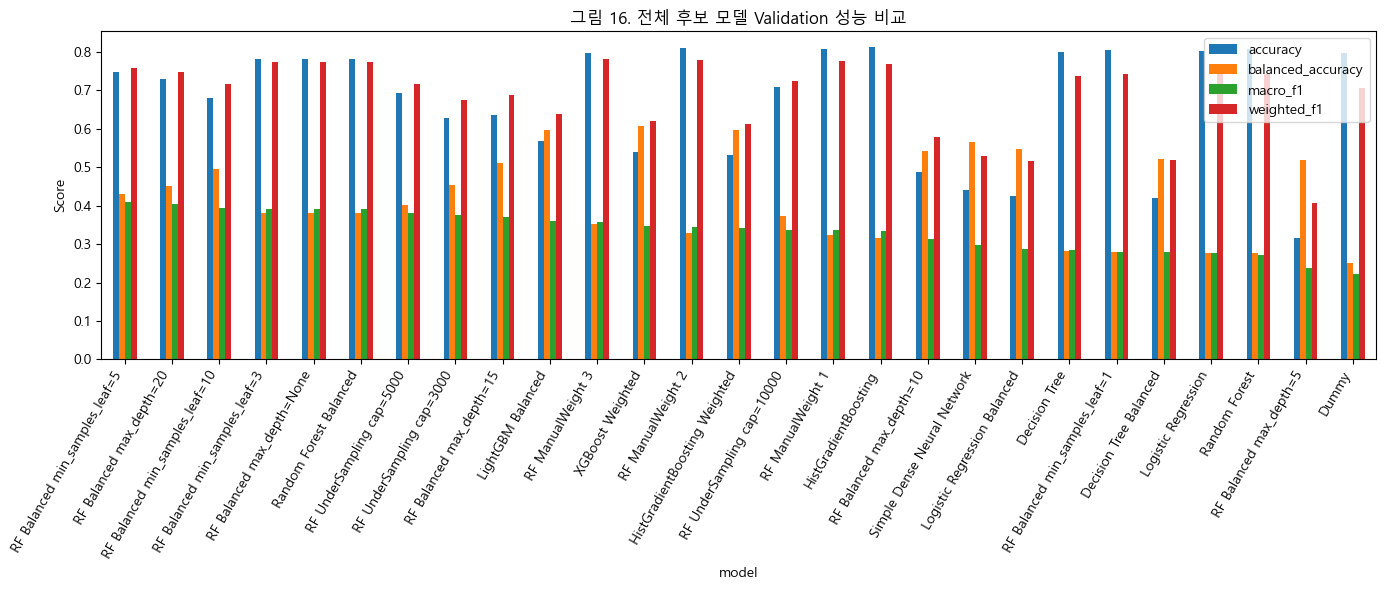

In [40]:
final_result_df = pd.DataFrame(candidate_val_results)
final_result_df = final_result_df.drop_duplicates(subset=["model"], keep="last")
final_result_df = final_result_df.sort_values(by="macro_f1", ascending=False).reset_index(drop=True)

print("표 23. 전체 후보 모델 Validation 성능 통합 비교")
display(final_result_df)

final_result_df.to_csv("outputs/model_validation_results_all_candidates.csv", index=False)

plot_df = final_result_df.set_index("model")[["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]]
plot_df.plot(kind="bar", figsize=(14, 6))
plt.title("그림 16. 전체 후보 모델 Validation 성능 비교")
plt.ylabel("Score")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.savefig("figures/fig16_all_candidate_validation_comparison.png", dpi=200)
plt.show()

## 27. 최종 모델 선택 및 Test set 평가

Validation set에서 `macro_f1`이 가장 높은 모델을 최종 모델로 선정한다.  
Test set은 모델 선택에 사용하지 않고, 최종 선택 이후 한 번만 평가한다.

In [41]:
best_model_name = final_result_df.iloc[0]["model"]
best_model = candidate_models[best_model_name]

print("최종 선택 모델:", best_model_name)
print("최종 선택 기준: Validation macro_f1 최대")
display(final_result_df.head(10))


def predict_with_final_model(model_name, X):
    """모델 종류에 따라 Test set 예측값을 동일한 Severity 1~4 형태로 반환한다."""
    model = candidate_models[model_name]

    if model_name == "Simple Dense Neural Network":
        X_nn = X.astype("float32").values
        pred_proba = model.predict(X_nn, verbose=0)
        return np.argmax(pred_proba, axis=1) + 1

    pred = model.predict(X)

    # XGBoost처럼 0~3 라벨로 학습한 모델은 예측 후 다시 Severity 1~4로 변환한다.
    if model_label_offset.get(model_name, 0) != 0:
        pred = pred + model_label_offset[model_name]

    return pred


test_pred = predict_with_final_model(best_model_name, test_scaled)

test_result = get_scores(best_model_name, test_target, test_pred)
test_result_df = pd.DataFrame([test_result])

print("표 24. 최종 모델 Test 성능")
display(test_result_df)

test_result_df.to_csv("outputs/model_test_result.csv", index=False)

per_class_report_df = pd.DataFrame(
    classification_report(test_target, test_pred, output_dict=True, zero_division=0)
).T

print("표 25. 최종 모델 클래스별 성능")
display(per_class_report_df)
per_class_report_df.to_csv("outputs/final_model_classification_report.csv", index=True)

최종 선택 모델: RF Balanced min_samples_leaf=5
최종 선택 기준: Validation macro_f1 최대


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,RF Balanced min_samples_leaf=5,0.748117,0.430753,0.396490,0.430753,0.409510,0.758353
1,RF Balanced max_depth=20,0.729254,0.452043,0.384064,0.452043,0.405475,0.748335
2,RF Balanced min_samples_leaf=10,0.680664,0.495244,0.372053,0.495244,0.394732,0.717152
3,RF Balanced min_samples_leaf=3,0.780910,0.381009,0.418601,0.381009,0.391259,0.775081
4,RF Balanced max_depth=None,0.780910,0.381009,0.418601,0.381009,0.391259,0.775081
5,Random Forest Balanced,0.780910,0.381009,0.418601,0.381009,0.391259,0.775081
6,RF UnderSampling cap=5000,0.694661,0.402263,0.436924,0.402263,0.380355,0.718082
7,RF UnderSampling cap=3000,0.627475,0.454540,0.371074,0.454540,0.375037,0.674403
8,RF Balanced max_depth=15,0.635606,0.510766,0.360522,0.510766,0.371030,0.688631
9,LightGBM Balanced,0.568686,0.595932,0.365498,0.595932,0.360116,0.639802


표 24. 최종 모델 Test 성능


,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,RF Balanced min_samples_leaf=5,0.741533,0.441725,0.404387,0.441725,0.418527,0.754584


표 25. 최종 모델 클래스별 성능


,precision,recall,f1-score,support
1,0.174157,0.236641,0.200647,131.000000
2,0.878721,0.805188,0.840349,11950.000000
3,0.407021,0.556305,0.470095,2522.000000
4,0.157647,0.168766,0.163017,397.000000
accuracy,0.741533,0.741533,0.741533,0.741533
macro avg,0.404387,0.441725,0.418527,15000.000000
weighted avg,0.774175,0.741533,0.754584,15000.000000


## 28. 최종 모델 Confusion Matrix

Confusion Matrix를 통해 실제 클래스와 예측 클래스의 관계를 확인한다.  
특히 소수 클래스인 Severity 1, 3, 4가 Severity 2로 과도하게 예측되는지 확인한다.

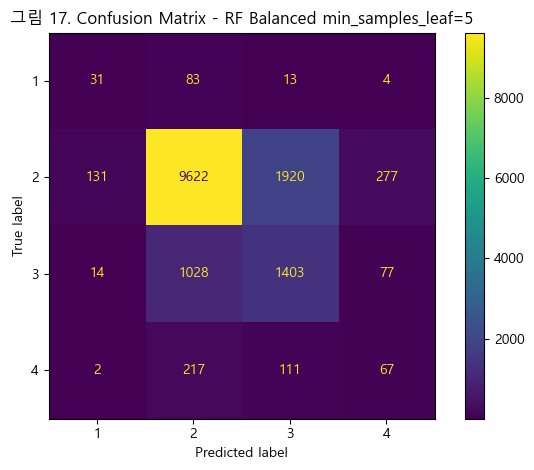

In [42]:
ConfusionMatrixDisplay.from_predictions(test_target, test_pred)
plt.title("그림 17. Confusion Matrix - " + best_model_name)
plt.tight_layout()
plt.savefig("figures/fig17_final_confusion_matrix.png", dpi=200)
plt.show()

## 29. 최종 모델 변수 중요도 또는 계수 확인

최종 모델이 트리 기반 모델이면 `feature_importances_`를, 선형 모델이면 `coef_`를 활용하여 상위 변수를 확인한다.  
변수 중요도는 모델이 예측 과정에서 상대적으로 많이 활용한 변수이며, 인과관계를 의미하지는 않는다.

표 26. 최종 모델 변수 중요도 상위 20개


,feature,importance
1,Start_Lng,0.075938
0,Start_Lat,0.074177
3,Wind_Chill(F),0.070990
22,Month,0.062361
5,Pressure(in),0.060341
2,Temperature(F),0.057167
24,Hour,0.056136
4,Humidity(%),0.048594
25,Precipitation_NA,0.040259
7,Wind_Speed(mph),0.038011


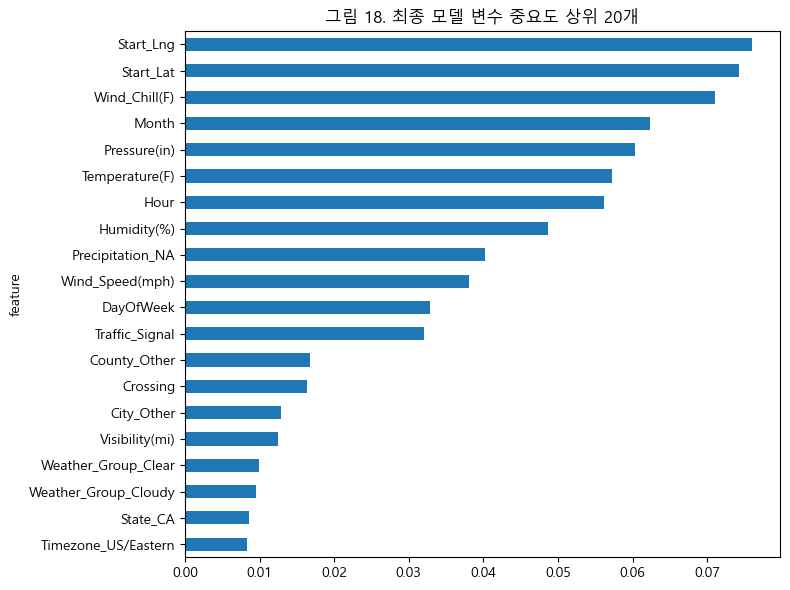

In [43]:
importance_df = None
final_model = candidate_models[best_model_name]

if best_model_name == "Simple Dense Neural Network":
    print("Neural Network는 현재 코드에서 변수 중요도를 직접 출력하지 않습니다.")

elif hasattr(final_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": train_scaled.columns,
        "importance": final_model.feature_importances_
    }).sort_values(by="importance", ascending=False)

elif hasattr(final_model, "coef_"):
    coef_values = np.mean(np.abs(final_model.coef_), axis=0)
    importance_df = pd.DataFrame({
        "feature": train_scaled.columns,
        "importance": coef_values
    }).sort_values(by="importance", ascending=False)

else:
    print("이 최종 모델은 현재 코드에서 변수 중요도 또는 계수를 직접 출력하지 않습니다.")

if importance_df is not None:
    print("표 26. 최종 모델 변수 중요도 상위 20개")
    display(importance_df.head(20))
    importance_df.to_csv("outputs/final_model_feature_importance.csv", index=False)

    importance_df.head(20).plot(
        x="feature",
        y="importance",
        kind="barh",
        figsize=(8, 6),
        legend=False
    )
    plt.title("그림 18. 최종 모델 변수 중요도 상위 20개")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig("figures/fig18_final_feature_importance.png", dpi=200)
    plt.show()

## 30. 보고서용 요약

최종 보고서에 사용할 핵심 정보를 출력하고 저장한다.

In [44]:
summary = {
    "original_shape": df.shape,
    "sampled_shape": sampled_df.shape,
    "processed_shape": data.shape,
    "encoded_feature_count": train_scaled.shape[1],
    "train_size": train_scaled.shape[0],
    "validation_size": val_scaled.shape[0],
    "test_size": test_scaled.shape[0],
    "best_model": best_model_name,
    "validation_macro_f1": final_result_df.iloc[0]["macro_f1"],
    "test_macro_f1": test_result["macro_f1"],
    "test_accuracy": test_result["accuracy"],
    "random_state": RANDOM_STATE,
    "sample_size": SAMPLE_SIZE
}

summary_df = pd.DataFrame([summary])
print("표 27. 최종 보고서 작성용 실험 요약")
display(summary_df)

summary_df.to_csv("outputs/experiment_summary.csv", index=False)

print("저장된 주요 파일")
print("- outputs/model_validation_results_all_candidates.csv")
print("- outputs/model_test_result.csv")
print("- outputs/final_model_classification_report.csv")
print("- outputs/final_model_feature_importance.csv")
print("- outputs/rf_depth_results.csv")
print("- outputs/rf_leaf_results.csv")
print("- outputs/nn_validation_result.csv")
print("- outputs/experiment_summary.csv")
print("- figures/*.png")

표 27. 최종 보고서 작성용 실험 요약


,original_shape,sampled_shape,processed_shape,encoded_feature_count,train_size,validation_size,test_size,best_model,validation_macro_f1,test_macro_f1,test_accuracy,random_state,sample_size
0,"(7728394, 34)","(100000, 34)","(100000, 37)",181,69997,15003,15000,RF Balanced min_samples_leaf=5,0.40951,0.418527,0.741533,42,100000


저장된 주요 파일
- outputs/model_validation_results_all_candidates.csv
- outputs/model_test_result.csv
- outputs/final_model_classification_report.csv
- outputs/final_model_feature_importance.csv
- outputs/rf_depth_results.csv
- outputs/rf_leaf_results.csv
- outputs/nn_validation_result.csv
- outputs/experiment_summary.csv
- figures/*.png


## 31. 최종 결론

본 프로젝트에서는 US Accidents 데이터를 활용하여 교통사고 심각도(`Severity`)를 4개 클래스로 분류하였다. 데이터는 `Severity=2` 클래스에 집중된 불균형 구조를 보였기 때문에 단순 정확도(`accuracy`)뿐만 아니라 `balanced accuracy`, `macro F1-score`, `weighted F1-score`를 함께 평가 지표로 사용하였다.

클래스 불균형 문제를 보완하기 위해 `stratify` 기반 데이터 분할, `class_weight`, `balanced_subsample`, `sample_weight`, 신경망의 `class_weight`를 적용하였다. 또한 XGBoost와 LightGBM을 추가 후보로 포함하여 다양한 모델을 동일한 Validation set에서 비교하였다.

최종 모델은 전체 후보 모델 중 Validation set에서 `macro F1-score`가 가장 높은 모델로 선정하였다. 이후 Test set에서 최종 성능을 확인하고, Confusion Matrix와 클래스별 성능표를 통해 다수 클래스인 Severity 2에만 편향되는지 점검하였다.

다만 소수 클래스의 예측 성능은 여전히 제한적일 수 있으므로, 향후에는 SMOTE와 같은 오버샘플링 기법, class weight 세부 조정, 임계값 조정, 추가적인 하이퍼파라미터 튜닝을 통해 Severity 1, 3, 4의 예측 성능을 개선할 필요가 있다.

## 32. 최종 체크리스트

제출 전 아래 내용을 확인한다.

- [ ] 노트북이 처음부터 끝까지 실행되는지 확인
- [ ] 원본 CSV 파일이 GitHub에 올라가지 않았는지 확인
- [ ] README.md 포함
- [ ] .gitignore 포함
- [ ] requirements.txt 포함
- [ ] outputs 폴더에 결과표 저장
- [ ] figures 폴더에 그래프 저장
- [ ] 보고서 수치와 노트북 결과가 일치하는지 확인
- [ ] 최종 보고서를 `Report/Submission` 폴더에 제출

In [45]:
# Streamlit 지도 기반 위치 자동 입력용 참조 데이터 저장 코드
# 노트북에서 streamlit_artifacts/severity_app_artifacts.joblib 저장 셀 근처에 추가해서 실행하세요.

from pathlib import Path

artifact_dir = Path("streamlit_artifacts")
artifact_dir.mkdir(parents=True, exist_ok=True)

location_ref_cols = ["Start_Lat", "Start_Lng", "State", "City", "County", "Timezone"]

# data는 노트북에서 전처리에 사용 중인 사고 데이터 DataFrame을 의미합니다.
# 만약 현재 노트북의 DataFrame 이름이 data가 아니라면 아래 data 부분만 실제 변수명으로 바꾸면 됩니다.
location_reference = data[location_ref_cols].copy()
location_reference = location_reference.dropna(subset=["Start_Lat", "Start_Lng"])
location_reference = location_reference.dropna(subset=["State", "City", "County", "Timezone"], how="all")
location_reference = location_reference.drop_duplicates()

# Streamlit 앱 로딩 속도를 위해 최대 100,000개만 저장
if len(location_reference) > 100_000:
    location_reference = location_reference.sample(n=100_000, random_state=42)

location_reference_path = artifact_dir / "location_reference.csv"
location_reference.to_csv(location_reference_path, index=False, encoding="utf-8-sig")

print("Streamlit 위치 참조 파일 저장 완료")
print("-", location_reference_path)
print("저장 행 수:", len(location_reference))


Streamlit 위치 참조 파일 저장 완료
- streamlit_artifacts\location_reference.csv
저장 행 수: 92101
